# DPAI — real-dataset baseline (MUSAN)

**Goal:** establish the reference baseline of the **original, unmodified DPAI** (Miotello et al., IEEE/ACM TASLP 2024) on **real public recordings**, before any enhancement is considered.

```
MUSAN (real recordings, OpenSLR SLR17, CC BY 4.0)
 → 20 clean clips (10 music, 10 speech), 5.000 s, 16 kHz mono         ← ground truth, never shown to DPAI
 → paper-protocol gaps: 200 / 400 / 600 / 800 / 1000 ms, 40–80 ms each (saved masks, fixed seeds)
 → corrupted audio
 → ORIGINAL DPAI (nets/best.json, Adam, lr 0.01, 5000 epochs)
 → reconstruction vs CLEAN audio: missing / transition / observed / whole-signal metrics
 → metrics.csv, metrics.json, aggregate.csv, plots, baseline_summary.md
```

**How to run**
1. `Runtime → Change runtime type → GPU` (T4 is enough). Sections 1–9 also work without a GPU; section 10 needs one.
2. Keep `USE_DRIVE = True` (cell 1.1). Results are written to Google Drive, so the experiment can continue across several Colab sessions.
3. `Runtime → Run all`. On the first session the notebook downloads MUSAN (10–11 GB, once) and prepares the 20 clips. Then it runs as many DPAI runs as fit into `MAX_SESSION_HOURS`.
4. In later sessions, run all again: finished runs are skipped automatically, and the metrics and report are rebuilt from everything finished so far.

Every number in the outputs is measured. Nothing is copied from the paper.

## 1. Project setup
### 1.1 Settings, folders and runtime check
**What:** sets every parameter of the experiment in one place, mounts Google Drive, creates the folder structure, and prints the Python, PyTorch and GPU information.
**Expected output:** the project folder, the GPU name (or a warning), and `1.1 OK`.

In [4]:
import os, sys, json, time, glob, shutil, subprocess, math, hashlib, importlib.util, platform, zipfile
from datetime import datetime

# ---------------- experiment settings (change here only) ----------------
USE_DRIVE         = True                 # store everything in Google Drive (needed to resume across sessions)
PROJECT_NAME      = "DPAI_real_baseline"
N_MUSIC, N_SPEECH = 10, 10               # 20 clips in total
SELECTION_SEED    = 2026                 # clip selection, segment selection and mask seeds derive from it
MIN_DURATION_S    = 15.0                 # only recordings >= 15 s are candidates (room for a 5-s window away from the edges)
MIN_WESTERN_ART   = 3                    # at least 3 classical recordings (stand-in for the paper's MAESTRO piano)
GAP_CONDITIONS_MS = [200, 400, 600, 800, 1000]          # paper Sec. IV-B
RUN_ORDER_MS      = [200, 1000, 600, 400, 800]          # order in which conditions are run (core first: 200, 1000, 600)
EPOCHS            = 5000                 # paper Sec. IV-E
LEARNING_RATE     = 0.01                 # paper Sec. IV-E (script.py default is 0.001)
NET_JSON          = "nets/best.json"     # anchors = paper Table I; 2,015,252 parameters
DPAI_SEED         = 0                    # same network initialisation / input noise for every run
SMOKE_EPOCHS      = 30
MAX_SESSION_HOURS = 10.0                 # stop starting new runs after this (Colab sessions are limited)
DPAI_REPO_URL     = "https://github.com/fmiotello/dpai"
DPAI_COMMIT       = "75074c9022e818685d3ae9bbfac894e30b9e368a"   # latest commit (26 Dec 2023), audited
MIN_ARCHIVE_BYTES = 9e9                  # musan.tar.gz is ~10-11 GB; a smaller file means an incomplete download
NEED_FREE_GB      = 26                   # archive + extracted music/speech
MUSAN_MIRRORS     = ["https://openslr.trmal.net/resources/17/musan.tar.gz",
                     "https://openslr.elda.org/resources/17/musan.tar.gz",
                     "https://openslr.magicdatatech.com/resources/17/musan.tar.gz",
                     "https://www.openslr.org/resources/17/musan.tar.gz"]
# ------------------------------------------------------------------------

BASE = os.environ.get("DPAI_BASE", "/content")
SESSION_START = time.time()
if USE_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        PROJECT_DIR = os.path.join("/content/drive/MyDrive", PROJECT_NAME)
    except ImportError:
        print("Not in Colab - using a local project folder.")
        PROJECT_DIR = os.path.join(BASE, PROJECT_NAME)
else:
    PROJECT_DIR = os.path.join(BASE, PROJECT_NAME)
D = {k: os.path.join(PROJECT_DIR, *v) for k, v in {
    "raw": ["dataset", "raw"], "clean": ["dataset", "clean"], "corrupted": ["dataset", "corrupted"], "masks": ["dataset", "masks"],
    "metadata": ["metadata"], "recon": ["reconstructions"], "metrics": ["metrics"], "plots": ["plots"],
    "logs": ["logs"], "reports": ["reports"]}.items()}
for p in D.values():
    os.makedirs(p, exist_ok=True)
SUPPORT_DIR = os.path.join(BASE, "dpai_support")
MUSAN_DL    = os.path.join(BASE, "musan_download")      # local disk only (never Drive)
MUSAN_DATA  = os.path.join(BASE, "musan_data")
SCRATCH     = os.path.join(BASE, "dpai_scratch")
for p in (SUPPORT_DIR, MUSAN_DL, MUSAN_DATA, SCRATCH):
    os.makedirs(p, exist_ok=True)

print("Project folder :", PROJECT_DIR)
print("Python         :", sys.version.split()[0])
import torch
print("PyTorch        :", torch.__version__, "| CUDA build", torch.version.cuda)
GPU_OK = torch.cuda.is_available()
if GPU_OK:
    GPU_CAP = torch.cuda.get_device_capability(0)
    print("GPU            :", torch.cuda.get_device_name(0), f"(compute {GPU_CAP[0]}.{GPU_CAP[1]})")
else:
    GPU_CAP = None
    print("GPU            : NONE - sections 1-9 will work; section 10 (DPAI) needs Runtime > Change runtime type > GPU.")
print("Free disk      :", round(shutil.disk_usage(BASE).free / 1e9, 1), "GB")
print("1.1 OK")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project folder : /content/drive/MyDrive/DPAI_real_baseline
Python         : 3.13.15
PyTorch        : 2.11.0+cu130 | CUDA build 13.0
GPU            : Tesla T4 (compute 7.5)
Free disk      : 75.4 GB
1.1 OK


### 1.2 Dependencies
**What:** installs only the packages that are missing: the extra imports of DPAI's `script.py` (`pesq`, `wandb`, `torchinfo`, `torch_intermediate_layer_getter`, `colorednoise`). PyTorch, NumPy and librosa are **not** upgraded.
**Expected output:** a version list and `1.2 OK`.

In [5]:
EXTRA = {"Cython": "cython", "pesq": "pesq", "wandb": "wandb", "torchinfo": "torchinfo",
         "torch_intermediate_layer_getter": "torch-intermediate-layer-getter", "colorednoise": "colorednoise"}
missing = [pip for mod, pip in EXTRA.items() if importlib.util.find_spec(mod) is None]
if missing:
    print("installing:", missing)
    r = subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--no-build-isolation", *missing], capture_output=True, text=True)
    print(r.stdout[-1500:], r.stderr[-2500:])
importlib.invalidate_caches()
VERSIONS = {"python": sys.version.split()[0], "platform": platform.platform()}
for mod in ["torch", "numpy", "scipy", "librosa", "soundfile", "pandas", "matplotlib", "sklearn", "skimage",
            "pesq", "wandb", "torchinfo", "torch_intermediate_layer_getter", "colorednoise"]:
    try:
        m = __import__(mod)
        VERSIONS[mod] = getattr(m, "__version__", "installed")
    except Exception as e:
        VERSIONS[mod] = f"MISSING ({type(e).__name__})"
VERSIONS["torch_cuda"] = torch.version.cuda
VERSIONS["cudnn"] = torch.backends.cudnn.version()
VERSIONS["gpu"] = torch.cuda.get_device_name(0) if GPU_OK else None
for k, v in VERSIONS.items():
    print(f"  {k:32s} {v}")
bad = [k for k, v in VERSIONS.items() if str(v).startswith("MISSING")]
if bad:
    raise RuntimeError(f"Missing packages: {bad}. ACTION: read the pip output, Runtime > Restart session, run again.")
print("1.2 OK")

installing: ['pesq', 'torchinfo', 'torch-intermediate-layer-getter', 'colorednoise']
 
  python                           3.13.15
  platform                         Linux-6.6.122+-x86_64-with-glibc2.39
  torch                            2.11.0+cu130
  numpy                            2.1.3
  scipy                            1.16.3
  librosa                          0.11.0
  soundfile                        0.14.0
  pandas                           2.2.3
  matplotlib                       3.10.0
  sklearn                          1.6.1
  skimage                          0.25.2
  pesq                             installed
  wandb                            0.28.1
  torchinfo                        1.8.0
  torch_intermediate_layer_getter  installed
  colorednoise                     installed
  torch_cuda                       13.0
  cudnn                            92700
  gpu                              Tesla T4
1.2 OK


### 1.3 Helper modules
**What:** writes the helper modules this notebook uses (they are also in the delivered ZIP). None of them changes the DPAI model.

| file | role |
|---|---|
| `musan_prep.py` | MUSAN catalogue, clip selection, 5-s standardisation, duplicate checks, paper-protocol masks, corrupted audio |
| `real_eval.py` | evaluation against the clean reference, aggregation, plots, summary report |
| `prepare_working_copy.py` | copies DPAI and applies the 3 documented harness patches (P1–P3) to the copy only |
| `setup_interp_same_cuda.py` | compiles DPAI's unmodified harmonic-convolution CUDA kernel |
| `run_dpai_seeded.py`, `dpai_runner.py` | run DPAI's own `script.py` with fixed seeds, logs and a time limit |
| `interp_same_reference.py` | pure-PyTorch reference of the CUDA kernel (kernel self-test only) |

In [6]:
%%writefile {SUPPORT_DIR}/musan_prep.py
"""
MUSAN -> DPAI real-data baseline: catalogue, clip selection, standardisation,
duplicate checks, paper-protocol masks and corrupted audio.

Dataset : MUSAN (Snyder, Chen, Povey, 2015), OpenSLR resource 17,
          https://www.openslr.org/17/  - CC BY 4.0 (per-file licences in LICENSE files).
Audio   : 16 kHz WAV (native - no resampling needed for MUSAN).

Nothing in this module touches the DPAI model.
"""
import hashlib
import math
import os

import numpy as np

SR = 16000
CLIP_S = 5.0
CLIP_N = int(SR * CLIP_S)              # 80,000 samples
N_FFT, HOP = 2048, 512                 # librosa.stft defaults used by DPAI's script.py
N_BINS = 1024                          # script.py keeps X[:1024, :208]
N_FRAMES = 1 + CLIP_N // HOP           # 157 frames for a 5-s clip (centre=True)
FRAME_MS = HOP / SR * 1000             # 32 ms

# Paper protocol (Sec. IV-B) + the argparse defaults of script.py (--min_gap 40 --max_gap 80 --context 150)
GAP_MIN_MS, GAP_MAX_MS, CONTEXT_MS = 40, 80, 150
GAP_TOTALS_MS = [200, 400, 600, 800, 1000]
TRIM_TOLERANCE_MS = 20                 # script.py: `while tot_hole_time*1e3 > args.tot_gap + 20`


class PrepError(RuntimeError):
    pass


# =============================================================================
# 1. Catalogue
# =============================================================================
def _read_keyed_lines(path):
    out = {}
    if not os.path.isfile(path):
        return out
    with open(path, encoding="utf-8", errors="replace") as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                out[parts[0].replace(".wav", "")] = parts[1:]
    return out


def build_catalog(musan_root, include=("music", "speech")):
    """One row per WAV in music/* and speech/* with annotations and licence."""
    import pandas as pd
    import soundfile as sf
    rows = []
    for category in include:
        cdir = os.path.join(musan_root, category)
        if not os.path.isdir(cdir):
            raise PrepError(f"{cdir} not found. ACTION: check MUSAN_ROOT (it must contain music/ and speech/).")
        for source in sorted(os.listdir(cdir)):
            sdir = os.path.join(cdir, source)
            if not os.path.isdir(sdir):
                continue
            ann = _read_keyed_lines(os.path.join(sdir, "ANNOTATIONS"))
            lic = _read_keyed_lines(os.path.join(sdir, "LICENSE"))
            for fn in sorted(os.listdir(sdir)):
                if not fn.lower().endswith(".wav"):
                    continue
                fid = fn[:-4]
                a = ann.get(fid, [])
                info = sf.info(os.path.join(sdir, fn))
                row = {"file_id": fid, "category": category, "musan_source": source,
                       "path": os.path.join(sdir, fn), "sr": info.samplerate, "channels": info.channels,
                       "frames": info.frames, "duration_s": round(info.duration, 3), "subtype": info.subtype,
                       "license": " ".join(lic.get(fid, [])) or None, "annotation_raw": " ".join(a)}
                if category == "music":
                    # MUSAN music ANNOTATIONS: <id> <genre[,genre...]> <vocals Y/N> <artist> [composer]
                    row["genres"] = a[0] if len(a) > 0 else None
                    row["vocals"] = a[1] if len(a) > 1 else None
                    row["artist"] = a[2] if len(a) > 2 else None
                    row["composer"] = a[3] if len(a) > 3 else None
                    row["group"] = row["artist"] or fid
                    row["stratum"] = ("western-art" if source in ("fma-western-art", "hd-classical")
                                      else (row["genres"] or "unknown").split(",")[0])
                else:
                    # MUSAN speech ANNOTATIONS: <id> <gender m/f> <language> [speaker]  (parsed defensively)
                    g = next((t for t in a if t.lower() in ("m", "f", "male", "female")), None)
                    row["gender"] = g[0].lower() if g else None
                    rest = [t for t in a if t != g]
                    row["language"] = rest[0] if rest else None
                    row["speaker"] = rest[1] if len(rest) > 1 else None
                    row["group"] = f"{source}:{row['speaker']}" if row["speaker"] else fid
                    row["stratum"] = f"{source}/{row['gender'] or 'u'}"
                rows.append(row)
    cat = pd.DataFrame(rows)
    if cat.empty:
        raise PrepError("No WAV files found under music/ and speech/.")
    return cat


# =============================================================================
# 2. Segment choice + quality checks
# =============================================================================
def load_mono_16k(path):
    import soundfile as sf
    x, sr = sf.read(path, always_2d=True, dtype="float64")
    notes = []
    if x.shape[1] > 1:
        x = x.mean(axis=1, keepdims=True)
        notes.append("downmixed to mono")
    y = x[:, 0]
    if sr != SR:
        import librosa
        y = librosa.resample(y, orig_sr=sr, target_sr=SR, res_type="soxr_hq")
        notes.append(f"resampled {sr}->{SR}")
    if not np.all(np.isfinite(y)):
        raise PrepError("non-finite samples")
    return y, sr, x.shape[1] if x.ndim == 2 else 1, notes


def frame_db(seg, n=2048, hop=512):
    nfr = 1 + (len(seg) - n) // hop
    e = np.array([np.mean(seg[i * hop:i * hop + n] ** 2) for i in range(nfr)])
    return 10 * np.log10(e + 1e-20)


def segment_quality(seg):
    db = frame_db(seg)
    mean_db = 10 * np.log10(np.mean(seg ** 2) + 1e-20)
    silent_frac = float(np.mean(db < mean_db - 30))      # frames >30 dB below the segment's mean energy
    peak = float(np.max(np.abs(seg)))
    rms_dbfs = 20 * np.log10(np.sqrt(np.mean(seg ** 2)) + 1e-20)
    clipped = float(np.mean(np.abs(seg) >= 0.999))
    return {"rms_dbfs": round(rms_dbfs, 2), "peak_dbfs": round(20 * np.log10(peak + 1e-20), 2),
            "silent_frame_fraction": round(silent_frac, 4), "clipped_fraction": round(clipped, 6),
            "dc_offset": round(float(np.mean(seg)), 6)}


def choose_segment(y, rng, skip_s=2.0, grid_s=0.5, max_silent=0.05, min_rms_dbfs=-45.0):
    """Random (seeded) 5-s window among windows that pass the quality rules.
    The first/last `skip_s` seconds are avoided (fade-ins/outs, silence)."""
    lo = int(skip_s * SR)
    hi = len(y) - CLIP_N - int(skip_s * SR)
    if hi < lo:  # short file: allow the whole range
        lo, hi = 0, len(y) - CLIP_N
    if hi < 0:
        raise PrepError(f"recording is {len(y)/SR:.2f}s, shorter than {CLIP_S}s")
    starts = np.arange(lo, hi + 1, int(grid_s * SR))
    ok = []
    for s in starts:
        q = segment_quality(y[s:s + CLIP_N])
        if q["silent_frame_fraction"] <= max_silent and q["rms_dbfs"] >= min_rms_dbfs and q["clipped_fraction"] == 0:
            ok.append((int(s), q))
    if not ok:
        raise PrepError("no 5-s window passes the quality rules (too much silence, too quiet, or clipped)")
    s, q = ok[int(rng.integers(len(ok)))]
    return s, q, len(ok), len(starts)


# =============================================================================
# 3. Clip selection (diversity + no duplicates)
# =============================================================================
def select_clips(catalog, n_music=10, n_speech=10, seed=2026, min_duration_s=15.0, min_western_art=3):
    """Round-robin over strata (genre for music, source/gender for speech) in a seeded order,
    one recording per artist/speaker, and each candidate must contain a valid 5-s window."""
    rng = np.random.default_rng(seed)
    picks, log, used_md5 = [], [], set()
    for category, n in (("music", n_music), ("speech", n_speech)):
        cand = catalog[(catalog["category"] == category) & (catalog["duration_s"] >= min_duration_s)].copy()
        if cand.empty:
            raise PrepError(f"no {category} recordings >= {min_duration_s}s")
        cand = cand.iloc[rng.permutation(len(cand))]
        strata = sorted(cand["stratum"].unique())
        strata = [strata[i] for i in rng.permutation(len(strata))]
        if category == "music" and "western-art" in strata:     # guarantee classical material (MAESTRO substitute)
            strata.remove("western-art")
            strata = ["western-art"] + strata
        queues = {s: list(cand[cand["stratum"] == s].index) for s in strata}
        used_groups, chosen, western = set(), [], 0
        while len(chosen) < n and any(queues.values()):
            for s in strata:
                if len(chosen) >= n:
                    break
                # music: fill the classical quota first
                if category == "music" and western < min_western_art and s != "western-art" and queues.get("western-art"):
                    continue
                while queues[s]:
                    i = queues[s].pop(0)
                    r = catalog.loc[i]
                    if r["group"] in used_groups:
                        continue
                    md5 = md5_file(r["path"])
                    if md5 in used_md5:
                        log.append({"file_id": r["file_id"], "rejected": "byte-identical to an already selected recording"})
                        continue
                    try:
                        y, sr0, ch, notes = load_mono_16k(r["path"])
                        start, q, n_ok, n_all = choose_segment(y, rng)
                    except PrepError as e:
                        log.append({"file_id": r["file_id"], "rejected": str(e)})
                        continue
                    used_groups.add(r["group"])
                    used_md5.add(md5)
                    chosen.append({"index": i, "segment_start_sample": start, "quality": q,
                                   "valid_windows": n_ok, "candidate_windows": n_all, "prep_notes": "; ".join(notes)})
                    if s == "western-art":
                        western += 1
                    break
        if len(chosen) < n:
            raise PrepError(f"only {len(chosen)} {category} clips could be selected (wanted {n})")
        picks.extend(chosen)
    return picks, log


# =============================================================================
# 4. Standardise + save clean clips
# =============================================================================
def md5_file(path):
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()


def write_clean_clips(catalog, picks, out_root, seed):
    import shutil
    import soundfile as sf
    import pandas as pd
    raw_dir, clean_dir = os.path.join(out_root, "raw"), os.path.join(out_root, "clean")
    os.makedirs(raw_dir, exist_ok=True)
    os.makedirs(clean_dir, exist_ok=True)
    rows = []
    n_m = n_s = 0
    for p in picks:
        r = catalog.loc[p["index"]]
        if r["category"] == "music":
            n_m += 1
            clip_id = f"M{n_m:02d}"
        else:
            n_s += 1
            clip_id = f"S{n_s:02d}"
        raw_copy = os.path.join(raw_dir, f"{r['file_id']}.wav")
        if not os.path.isfile(raw_copy):
            shutil.copy2(r["path"], raw_copy)             # untouched copy of the original file
        y, sr0, ch, notes = load_mono_16k(r["path"])
        s = p["segment_start_sample"]
        seg = y[s:s + CLIP_N]
        out = os.path.join(clean_dir, f"{clip_id}.wav")
        sf.write(out, seg.astype(np.float32), SR, subtype="FLOAT")
        chk = verify_clip(out)
        rows.append({
            "clip_id": clip_id, "source_dataset": "MUSAN (OpenSLR SLR17)", "category": r["category"],
            "musan_source": r["musan_source"], "source_file": f"{r['category']}/{r['musan_source']}/{r['file_id']}.wav",
            "genre_or_category": r.get("genres") if r["category"] == "music" else f"speech ({r.get('language') or '?'})",
            "vocals": r.get("vocals"), "artist_or_speaker": r.get("artist") if r["category"] == "music" else (r.get("speaker") or r["file_id"]),
            "gender": r.get("gender"), "license": r["license"],
            "original_sample_rate": int(r["sr"]), "original_channels": int(r["channels"]),
            "original_duration_s": r["duration_s"], "processed_sample_rate": SR,
            "duration": chk["duration_s"], "channels": chk["channels"], "samples": chk["samples"],
            "segment_start": round(s / SR, 3), "segment_end": round((s + CLIP_N) / SR, 3),
            "random_seed": seed, "valid_windows": p["valid_windows"], "candidate_windows": p["candidate_windows"],
            **{k: v for k, v in p["quality"].items()},
            "source_md5": md5_file(r["path"]), "clean_md5": md5_file(out),
            "quality_check": "PASS" if chk["ok"] else "FAIL: " + "; ".join(chk["problems"]),
            "prep_notes": p["prep_notes"] or "none (already 16 kHz mono)",
        })
    return pd.DataFrame(rows)


def verify_clip(path):
    import soundfile as sf
    info = sf.info(path)
    y, sr = sf.read(path)
    problems = []
    if sr != SR:
        problems.append(f"sample rate {sr}")
    if info.channels != 1:
        problems.append(f"{info.channels} channels")
    if len(y) != CLIP_N:
        problems.append(f"{len(y)} samples (expected {CLIP_N})")
    if not np.all(np.isfinite(y)):
        problems.append("non-finite samples")
    if np.sqrt(np.mean(y ** 2)) < 10 ** (-45 / 20):
        problems.append("silent / too quiet")
    if np.max(np.abs(y)) >= 0.999:
        problems.append("clipping")
    return {"ok": not problems, "problems": problems, "sr": sr, "channels": info.channels,
            "samples": len(y), "duration_s": round(len(y) / sr, 4)}


def duplicate_checks(meta, clean_dir, ncc_threshold=0.9):
    """Exact duplicates (MD5), same artist/speaker, same source file, and near-duplicates by
    normalised cross-correlation of the 5-s clips."""
    import soundfile as sf
    issues = []
    for col in ("source_md5", "clean_md5", "source_file"):
        d = meta[meta.duplicated(col, keep=False)]
        if len(d):
            issues.append(f"duplicate {col}: {sorted(d['clip_id'])}")
    for cat in ("music", "speech"):
        sub = meta[meta["category"] == cat]
        d = sub[sub.duplicated("artist_or_speaker", keep=False) & sub["artist_or_speaker"].notna()]
        if len(d):
            issues.append(f"same {'artist' if cat == 'music' else 'speaker'} used twice: {sorted(d['clip_id'])}")
    clips = {c: sf.read(os.path.join(clean_dir, f"{c}.wav"))[0] for c in meta["clip_id"]}
    ids = list(clips)
    nfft = 1 << int(math.ceil(math.log2(2 * CLIP_N)))
    F = {c: np.fft.rfft((v - v.mean()) / (np.linalg.norm(v - v.mean()) + 1e-12), nfft) for c, v in clips.items()}
    max_ncc = 0.0
    for i in range(len(ids)):
        for j in range(i + 1, len(ids)):
            r = np.fft.irfft(F[ids[i]] * np.conj(F[ids[j]]), nfft)
            m = float(np.max(np.abs(r)))
            max_ncc = max(max_ncc, m)
            if m >= ncc_threshold:
                issues.append(f"near-duplicate audio {ids[i]} / {ids[j]} (NCC {m:.3f})")
    return issues, round(max_ncc, 4)


# =============================================================================
# 5. Paper-protocol masks
# =============================================================================
def generate_time_holes(rng, length=CLIP_N, total_ms=600, min_ms=GAP_MIN_MS, max_ms=GAP_MAX_MS, context_ms=CONTEXT_MS):
    """Seeded re-implementation of generate_time_mask() in src/utils/common_utils.py.

    Same rules: random start, length uniform in [min, max) ms, last hole truncated to reach the
    exact total, each hole must have `context` ms of untouched audio after it and not overlap
    earlier holes+context, no hole in the first `context` ms; after 1000 attempts fall back to
    evenly spaced holes.
    Two bugs of the original are fixed (documented in the report): holes may not run past the
    end of the signal, and the fallback places all holes inside the signal and discards the
    partial random placement."""
    gl = int(total_ms * 1e-3 * SR)
    hmin, hmax, ctx = int(min_ms * 1e-3 * SR), int(max_ms * 1e-3 * SR), int(context_ms * 1e-3 * SR)
    usable = np.ones(length, bool)
    usable[:ctx] = False
    holes, total, it = [], 0, 0
    while total < gl:
        if it > 1000:
            single = (hmax + hmin) // 2
            n = max(1, int(round(gl / single)))
            step = (length - ctx) // (n + 1)
            holes = [(ctx + step * (i + 1) - single // 2, ctx + step * (i + 1) - single // 2 + single) for i in range(n)]
            return sorted(holes), "fallback_even"
        idx = int(rng.integers(0, length))
        L = int(rng.integers(hmin, hmax))
        L = min(L, gl - total)
        if idx + L + ctx <= length and usable[idx:idx + L + ctx].all():
            holes.append((idx, idx + L))
            usable[idx:idx + L + ctx] = False
            total += L
        it += 1
    return sorted(holes), "random"


def frame_mask_from_time_holes(holes, length=CLIP_N):
    """Authors' rule (commented code in script.py): STFT of the 0/1 time mask; a frame is kept
    only if its DC bin equals the maximum, i.e. its analysis window touches no hole.
    pad_mode='reflect' = librosa's default when DPAI was written (< 0.10)."""
    import librosa
    m = np.ones(length)
    for a, b in holes:
        m[a:b] = 0
    S = librosa.stft(m, n_fft=N_FFT, hop_length=HOP, center=True, pad_mode="reflect")
    dc = np.abs(S[0, :])
    keep = np.isclose(dc / dc.max(), 1.0, rtol=0, atol=1e-9)
    return keep.astype(int)[:N_FRAMES]


def frame_gaps(keep):
    gaps, i = [], 0
    while i < len(keep):
        if keep[i] == 0:
            j = i
            while j < len(keep) and keep[j] == 0:
                j += 1
            gaps.append((i, j))
            i = j
        else:
            i += 1
    return gaps


def trim_to_target(keep, total_ms, rng, tol_ms=TRIM_TOLERANCE_MS):
    """Authors' loop: while masked-frame time > total + 20 ms, give back the last frame of a gap
    that is longer than one frame. The commented code picks that gap at random, which can leave
    single gaps of 160 ms or more; the paper states gaps of 40-80 ms, so here the LONGEST gap is
    shortened first (ties broken at random). With 32-ms frames this keeps gaps at 1-3 frames
    (32-96 ms), the closest achievable to 40-80 ms. The original's off-by-one in gap detection
    is also fixed."""
    keep = keep.copy()
    for _ in range(10000):
        gaps = frame_gaps(keep)
        tot = sum(b - a for a, b in gaps) * FRAME_MS
        if tot <= total_ms + tol_ms:
            return keep
        longest = max(b - a for a, b in gaps)
        if longest <= 1:
            return keep   # cannot shrink further: every gap is a single frame
        cands = [g for g in gaps if g[1] - g[0] == longest]
        a, b = cands[int(rng.integers(len(cands)))]
        keep[b - 1] = 1
    return keep


def make_mask(seed, total_ms):
    rng = np.random.default_rng(seed)
    holes, mode = generate_time_holes(rng, total_ms=total_ms)
    keep0 = frame_mask_from_time_holes(holes)
    keep = trim_to_target(keep0, total_ms, rng)
    gaps = frame_gaps(keep)
    if not gaps:
        raise PrepError("empty mask")
    if keep.sum() == 0:
        raise PrepError("mask removes every frame")
    mask2d = np.tile(keep[None, :], (N_BINS, 1)).astype(np.float64)       # shape (1024, 157) like X in script.py
    return {
        "seed": int(seed), "target_total_ms": total_ms, "placement": mode,
        "time_holes_samples": [list(map(int, h)) for h in holes],
        "time_holes_ms": [[round(a / SR * 1000, 1), round(b / SR * 1000, 1)] for a, b in holes],
        "frames_masked_before_trim": int((keep0 == 0).sum()),
        "gap_frames": [[int(a), int(b)] for a, b in gaps],                      # [start, end) frame indices
        # frame l is centred on sample l*HOP (librosa centre=True), so a gap of frames [a, b) owns the samples
        # [a*HOP - HOP/2, (b-1)*HOP + HOP/2). (The authors' commented code used [a*HOP, b*HOP), which ignores centring.)
        "gap_samples": [[max(0, int(a * HOP - HOP // 2)), min(CLIP_N, int((b - 1) * HOP + HOP // 2))] for a, b in gaps],
        "gap_locations_s": [[round(max(0, a * HOP - HOP // 2) / SR, 4), round(min(CLIP_N, (b - 1) * HOP + HOP // 2) / SR, 4)] for a, b in gaps],
        "gap_durations_ms": [round((b - a) * FRAME_MS, 1) for a, b in gaps],
        "gap_count": len(gaps), "total_gap_ms": round(sum(b - a for a, b in gaps) * FRAME_MS, 1),
        "masked_frames": int((keep == 0).sum()), "n_frames": N_FRAMES,
    }, mask2d


def corrupt(clean, mask2d):
    """Corrupted audio as a listener would hear it: STFT (n_fft 2048, hop 512, Hann), zero the
    masked frames (all 1025 bins), inverse STFT to exactly 80,000 samples."""
    import librosa
    X = librosa.stft(clean, n_fft=N_FFT, hop_length=HOP)
    keep = mask2d[0, :X.shape[1]]
    return librosa.istft(X * keep[None, :], n_fft=N_FFT, hop_length=HOP, length=len(clean))


def run_seed(base_seed, clip_index, total_ms):
    return int(base_seed * 100000 + clip_index * 1000 + total_ms)


Writing /content/dpai_support/musan_prep.py


In [7]:
%%writefile {SUPPORT_DIR}/real_eval.py
"""
Evaluation of the ORIGINAL DPAI on real clips against the TRUE clean reference.

For every run (clip x gap condition):
  * the DPAI output spectrogram saved by script.py (patch P3) is resynthesised on the
    original time axis (n_fft 2048, hop 512, Hann, 80,000 samples), the same STFT
    convention that created the clean clip and the corrupted audio;
  * the clean clip WAV (ground truth) is compared with:
      - the corrupted audio            ("corrupted",  the before value),
      - the DPAI output                ("dpai",       primary result),
      - DPAI output with the observed frames replaced by the corrupted input's frames
        ("dpai_ctx"; observed frames are what the model was given, so this is legal);
  * metrics are computed separately on the MISSING region (primary), the TRANSITION zone,
    the OBSERVED region and the WHOLE signal;
  * PESQ (wide-band, 16 kHz) only for speech clips.
"""
import json
import math
import os

import numpy as np

SR, N_FFT, HOP, CLIP_N, N_BINS = 16000, 2048, 512, 80000, 1024


class EvalError(RuntimeError):
    pass


# ----------------------------------------------------------------------------- signals
def native_istft(spec_2ch):
    """(2, 1024, F) real/imag -> waveform on the original 80,000-sample axis.
    The dropped Nyquist bin (index 1024) is set to zero."""
    import librosa
    re_, im_ = spec_2ch[0], spec_2ch[1]
    Z = np.zeros((N_BINS + 1, re_.shape[1]), complex)
    Z[:N_BINS] = re_ + 1j * im_
    return librosa.istft(Z, n_fft=N_FFT, hop_length=HOP, length=CLIP_N)


def clean_spectrogram(clean):
    import librosa
    return librosa.stft(clean, n_fft=N_FFT, hop_length=HOP)


def reference_floor_db(clean):
    """Error caused only by DPAI's representation (Nyquist bin dropped), with no inpainting."""
    X = clean_spectrogram(clean)
    rec = native_istft(np.stack([X[:N_BINS].real, X[:N_BINS].imag]))
    return 10 * math.log10(np.sum((rec - clean) ** 2) / np.sum(clean ** 2) + 1e-30)


def with_context(clean, spec_2ch, keep):
    """Observed frames from the corrupted input (= clean in observed frames), missing frames from DPAI."""
    import librosa
    X = clean_spectrogram(clean)
    Y = np.zeros_like(X)
    Y[:N_BINS] = spec_2ch[0] + 1j * spec_2ch[1]
    k = keep[None, :X.shape[1]]
    Z = X * k + Y * (1 - k)
    return librosa.istft(Z, n_fft=N_FFT, hop_length=HOP, length=CLIP_N)


# ----------------------------------------------------------------------------- regions
def regions(gap_frames, n=CLIP_N):
    """missing    : [a*512-256, (b-1)*512+256) for every masked frame run [a, b): the samples whose nearest
                   frame centre is a masked frame (librosa centre=True puts frame l at sample l*512)
       transition : touched by the analysis/synthesis window of a masked frame but not 'missing'
       observed   : not touched by any masked frame's window
       all        : the whole clip"""
    missing = np.zeros(n, bool)
    touched = np.zeros(n, bool)
    for a, b in gap_frames:
        missing[max(0, a * HOP - HOP // 2):min(n, (b - 1) * HOP + HOP // 2)] = True
        touched[max(0, a * HOP - N_FFT // 2):min(n, (b - 1) * HOP + N_FFT // 2)] = True
    if not missing.any():
        raise EvalError("missing region is empty")
    observed = ~(touched | missing)
    if not observed.any():
        raise EvalError("observed region is empty")
    return {"missing": missing, "transition": touched & ~missing, "observed": observed, "all": np.ones(n, bool)}


def region_metrics(ref, est, sel):
    r, e = ref[sel], est[sel]
    n = int(sel.sum())
    out = {"n_samples": n, "seconds": round(n / SR, 4)}
    if n == 0:
        return {**out, "note": "empty region"}
    err = float(np.sum((e - r) ** 2))
    en = float(np.sum(r ** 2))
    out["rmse"] = math.sqrt(err / n)
    if en <= 1e-12:
        return {**out, "nmse_lin": None, "nmse_db": None, "snr_db": None, "nrmse": None,
                "note": "reference energy ~0 in region: normalised metrics undefined"}
    out["nmse_lin"] = err / en
    out["nrmse"] = math.sqrt(err / en)
    out["nmse_db"] = 10 * math.log10(err / en) if err > 0 else float("-inf")
    out["snr_db"] = -out["nmse_db"]
    return out


def lag(ref, est, max_lag=1024):
    size = 1 << int(math.ceil(math.log2(2 * len(ref))))
    r = np.fft.irfft(np.fft.rfft(est, size) * np.conj(np.fft.rfft(ref, size)), size)
    lags = np.concatenate([np.arange(0, max_lag + 1), np.arange(-max_lag, 0)])
    return int(lags[int(np.argmax(np.concatenate([r[:max_lag + 1], r[-max_lag:]])))])


def pesq_wb(ref, deg):
    try:
        from pesq import pesq
        return float(pesq(SR, ref.astype(np.float64), deg.astype(np.float64), "wb"))
    except Exception:
        return None


# ----------------------------------------------------------------------------- one run
def evaluate_run(clean_path, corrupted_path, run_dir, mask_info, mask2d, category, clean_md5=None):
    import soundfile as sf
    import hashlib
    checks, problems = {}, []
    clean, sr_c = sf.read(clean_path)
    corr, sr_k = sf.read(corrupted_path)
    if clean_md5:
        checks["reference_is_clean_file"] = hashlib.md5(open(clean_path, "rb").read()).hexdigest() == clean_md5
        if not checks["reference_is_clean_file"]:
            problems.append("clean file changed since dataset preparation")
    for name, (x, s) in {"clean": (clean, sr_c), "corrupted": (corr, sr_k)}.items():
        if s != SR or x.ndim != 1 or len(x) != CLIP_N:
            problems.append(f"{name}: sr {s}, shape {x.shape} (expected {SR} Hz mono {CLIP_N})")
    spec_p = os.path.join(run_dir, "output_spectrogram.npy")
    if not os.path.isfile(spec_p):
        raise EvalError(f"{spec_p} missing - the run did not finish or patch P3 is not applied.")
    spec = np.load(spec_p)
    if spec.shape != (2, N_BINS, mask2d.shape[1]):
        problems.append(f"output spectrogram shape {spec.shape}")
    used_mask = np.load(os.path.join(run_dir, "mask.npy"))
    checks["mask_used_by_dpai_equals_saved_mask"] = bool(used_mask.shape == mask2d.shape and np.array_equal(used_mask, mask2d))
    if not checks["mask_used_by_dpai_equals_saved_mask"]:
        problems.append("the mask DPAI used differs from the saved experiment mask")
    keep = mask2d[0].astype(int)
    reg = regions(mask_info["gap_frames"])
    dpai = native_istft(spec)
    ctx = with_context(clean, spec, keep)
    # the corrupted signal must differ from the clean one inside the gaps (otherwise we would evaluate the wrong thing)
    miss_corr = region_metrics(clean, corr, reg["missing"])
    checks["corrupted_differs_from_clean_in_gaps"] = bool(miss_corr.get("nmse_db") is not None and miss_corr["nmse_db"] > -10)
    if not checks["corrupted_differs_from_clean_in_gaps"]:
        problems.append("corrupted audio is (almost) identical to clean audio inside the gaps")
    obs_corr = region_metrics(clean, corr, reg["observed"])
    checks["corrupted_equals_clean_in_observed_region_db"] = obs_corr.get("nmse_db")
    if obs_corr.get("nmse_db") is not None and obs_corr["nmse_db"] > -60:
        problems.append("corrupted audio differs from clean audio in the observed region")
    checks["lag_dpai_ctx"] = lag(clean, ctx)
    checks["lag_dpai"] = lag(clean, dpai)
    if checks["lag_dpai_ctx"] != 0:
        problems.append(f"time misalignment: lag {checks['lag_dpai_ctx']} samples")
    checks["representation_floor_db"] = round(reference_floor_db(clean), 2)

    rows = []
    for sig_name, est in (("corrupted", corr), ("dpai", dpai), ("dpai_ctx", ctx)):
        for rname, sel in reg.items():
            m = region_metrics(clean, est, sel)
            rows.append({"signal": sig_name, "region": rname, **m})
    pesq_vals = {}
    if category == "speech":
        pesq_vals = {"pesq_corrupted": pesq_wb(clean, corr), "pesq_dpai": pesq_wb(clean, dpai), "pesq_dpai_ctx": pesq_wb(clean, ctx)}
        if pesq_vals["pesq_corrupted"] is not None and pesq_vals["pesq_dpai"] is not None:
            pesq_vals["delta_pesq"] = pesq_vals["pesq_dpai"] - pesq_vals["pesq_corrupted"]
    checks["problems"] = problems
    return rows, pesq_vals, checks, {"dpai": dpai, "dpai_ctx": ctx}


def flatten(clip_meta, cond_ms, mask_info, rows, pesq_vals, checks, runtime_s, run_status, repo_metrics):
    """One wide row per run for metrics.csv."""
    out = {"run_id": f"{clip_meta['clip_id']}_gap{cond_ms}", "clip_id": clip_meta["clip_id"],
           "category": clip_meta["category"], "genre_or_category": clip_meta["genre_or_category"],
           "musan_source": clip_meta["musan_source"], "gap_condition_ms": cond_ms,
           "gap_count": mask_info["gap_count"], "total_gap_ms": mask_info["total_gap_ms"],
           "gap_durations_ms": json.dumps(mask_info["gap_durations_ms"]), "seed": mask_info["seed"],
           "runtime_s": runtime_s, "status": run_status, "checks_passed": not checks["problems"],
           "check_problems": "; ".join(checks["problems"]), "lag_dpai": checks["lag_dpai"],
           "representation_floor_db": checks["representation_floor_db"]}
    for r in rows:
        k = f"{r['signal']}_{r['region']}"
        for m in ("nmse_db", "snr_db", "rmse", "nrmse", "nmse_lin"):
            out[f"{k}_{m}"] = r.get(m)
        out[f"{r['region']}_seconds"] = r.get("seconds")
    out.update({k: v for k, v in pesq_vals.items()})
    for k in ("nmse_spectrogram", "nmse_audio", "nmse_audio_masked_part", "pesq_before", "pesq_after", "elapsed_time",
              "last_training_loss", "last_validation_loss"):
        out[f"repo_{k}"] = repo_metrics.get(k) if repo_metrics else None
    return out


# ----------------------------------------------------------------------------- aggregation
KEY_METRICS = [
    ("dpai_missing_nmse_db", "NMSE missing [dB] (DPAI)"),
    ("corrupted_missing_nmse_db", "NMSE missing [dB] (corrupted)"),
    ("dpai_missing_snr_db", "SNR missing [dB] (DPAI)"),
    ("dpai_missing_rmse", "RMSE missing (DPAI)"),
    ("dpai_all_nmse_db", "NMSE overall [dB] (DPAI)"),
    ("dpai_ctx_all_nmse_db", "NMSE overall [dB] (DPAI + observed context)"),
    ("dpai_observed_nmse_db", "NMSE observed [dB] (DPAI)"),
    ("delta_pesq", "dPESQ (speech only)"),
    ("runtime_s", "runtime per run [s]"),
]


def bootstrap_ci(x, rng, n=2000, alpha=0.05):
    x = np.asarray(x, float)
    if len(x) < 2:
        return (None, None)
    means = np.array([np.mean(rng.choice(x, len(x))) for _ in range(n)])
    return (float(np.quantile(means, alpha / 2)), float(np.quantile(means, 1 - alpha / 2)))


def aggregate(df, seed=0):
    import pandas as pd
    rng = np.random.default_rng(seed)
    ok = df[(df["status"] == "ok") & (df["checks_passed"])]
    rows = []
    for cond in sorted(ok["gap_condition_ms"].unique()):
        for cat in ("all", "music", "speech"):
            sub = ok[ok["gap_condition_ms"] == cond] if cat == "all" else ok[(ok["gap_condition_ms"] == cond) & (ok["category"] == cat)]
            if sub.empty:
                continue
            row = {"gap_condition_ms": int(cond), "category": cat, "n_runs": len(sub)}
            for col, _ in KEY_METRICS:
                v = pd.to_numeric(sub[col], errors="coerce").dropna() if col in sub else pd.Series(dtype=float)
                if v.empty:
                    continue
                lo, hi = bootstrap_ci(v.values, rng)
                row.update({f"{col}_mean": v.mean(), f"{col}_std": v.std(ddof=1) if len(v) > 1 else None,
                            f"{col}_median": v.median(), f"{col}_ci95_lo": lo, f"{col}_ci95_hi": hi, f"{col}_n": len(v)})
            # paper Eq. (16): NMSE = 10 log10( mean_i ||x_hat_i - x_i||^2 / ||x_i||^2 )
            for sig, reg in (("dpai", "missing"), ("dpai", "all"), ("corrupted", "missing")):
                lin = pd.to_numeric(sub.get(f"{sig}_{reg}_nmse_lin"), errors="coerce").dropna()
                if len(lin):
                    row[f"paper_eq16_{sig}_{reg}_db"] = 10 * math.log10(lin.mean())
            rows.append(row)
    return pd.DataFrame(rows)


# ----------------------------------------------------------------------------- plots
def plot_condition_curves(agg, path):
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
    specs = [("dpai_missing_nmse_db", "NMSE in missing regions [dB]"), ("dpai_all_nmse_db", "NMSE overall [dB]"),
             ("delta_pesq", "dPESQ (speech)")]
    colors = {"all": "#1f4e79", "music": "#c55a11", "speech": "#548235"}
    for ax, (col, title) in zip(axes, specs):
        for cat in ("all", "music", "speech"):
            s = agg[agg["category"] == cat].sort_values("gap_condition_ms")
            if f"{col}_mean" not in s or s[f"{col}_mean"].isna().all():
                continue
            ax.errorbar(s["gap_condition_ms"], s[f"{col}_mean"], yerr=s.get(f"{col}_std"), marker="o", capsize=3,
                        label=cat, color=colors[cat])
        if col == "dpai_missing_nmse_db":
            s = agg[agg["category"] == "all"].sort_values("gap_condition_ms")
            if "corrupted_missing_nmse_db_mean" in s:
                ax.plot(s["gap_condition_ms"], s["corrupted_missing_nmse_db_mean"], "k--", marker="x", lw=1, label="corrupted input (before)")
        ax.set_title(title)
        ax.set_xlabel("cumulative gap duration [ms]")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(path, dpi=130)
    plt.close(fig)


def plot_per_clip(df, path):
    import matplotlib.pyplot as plt
    ok = df[(df["status"] == "ok") & (df["checks_passed"])]
    piv = ok.pivot_table(index="clip_id", columns="gap_condition_ms", values="dpai_missing_nmse_db")
    if piv.empty:
        return
    fig, ax = plt.subplots(figsize=(1.2 * piv.shape[1] + 3, 0.35 * piv.shape[0] + 1.5))
    im = ax.imshow(piv.values, aspect="auto", cmap="viridis_r")
    ax.set_xticks(range(piv.shape[1]), [f"{c} ms" for c in piv.columns])
    ax.set_yticks(range(piv.shape[0]), piv.index)
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            v = piv.values[i, j]
            if np.isfinite(v):
                ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=7, color="white")
    fig.colorbar(im, ax=ax, label="NMSE missing [dB] (lower is better)")
    ax.set_title("Per-clip DPAI NMSE inside the gaps")
    fig.tight_layout()
    fig.savefig(path, dpi=130)
    plt.close(fig)


def plot_example(clean, corr, dpai, gap_frames, title, path):
    import librosa
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(2, 3, figsize=(16, 6), gridspec_kw={"height_ratios": [1, 1.4]})
    t = np.arange(len(clean)) / SR
    ref = np.max(np.abs(librosa.stft(clean)))
    for j, (sig, name) in enumerate(((clean, "clean (ground truth)"), (corr, "corrupted (DPAI input)"), (dpai, "DPAI output"))):
        axes[0, j].plot(t, sig, lw=0.4, color="#1f4e79")
        for a, b in gap_frames:
            axes[0, j].axvspan((a * HOP - HOP // 2) / SR, ((b - 1) * HOP + HOP // 2) / SR, color="tab:red", alpha=0.25, lw=0)
        axes[0, j].set_title(name)
        axes[0, j].set_ylim(-1.05 * np.max(np.abs(clean)), 1.05 * np.max(np.abs(clean)))
        D = librosa.amplitude_to_db(np.abs(librosa.stft(sig.astype(np.float32))), ref=ref)
        axes[1, j].imshow(D[:1024], origin="lower", aspect="auto", vmin=-80, vmax=0, extent=[0, len(sig) / SR, 0, 8000], cmap="viridis")
        axes[1, j].set_xlabel("time [s]")
    axes[1, 0].set_ylabel("Hz")
    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(path, dpi=110)
    plt.close(fig)


# ----------------------------------------------------------------------------- report
def _f(v, nd=2):
    if v is None or (isinstance(v, float) and not math.isfinite(v)):
        return "n/a"
    return f"{v:.{nd}f}"


def write_summary(path, ctx, meta, exp, df, agg):
    L = ["# DPAI real-dataset baseline - summary", ""]
    L.append("All values below are computed from the runs listed in `metrics/metrics.csv`. "
             "Runs whose checks failed or that did not finish are excluded from the averages and listed separately.\n")
    L += ["## Dataset", ""]
    L.append(f"- Source: MUSAN (OpenSLR SLR17, CC BY 4.0; per-file licences in `metadata/dataset_metadata.csv`). Archive SHA-256: `{ctx.get('archive_sha256')}`")
    L.append(f"- Clips: {len(meta)} ({(meta['category']=='music').sum()} music, {(meta['category']=='speech').sum()} speech), 5.000 s, 16 kHz mono, selection seed {ctx.get('seed')}")
    L.append(f"- Music genres: {', '.join(sorted(set(meta.loc[meta['category']=='music','genre_or_category'].astype(str))))}")
    L.append(f"- Speech sources: {', '.join(sorted(set(meta.loc[meta['category']=='speech','musan_source'].astype(str))))}")
    L.append(f"- Quality checks: {(meta['quality_check']=='PASS').sum()}/{len(meta)} PASS; duplicate checks: {ctx.get('duplicate_issues') or 'none found'} (max NCC between clips {ctx.get('max_ncc')})\n")
    L += ["## Preprocessing", ""]
    L.append("Mono (channel average) → 16 kHz (MUSAN is native 16 kHz; no resampling occurred unless stated per clip) → seeded random 5-s window "
             "among windows with ≤5 % frames more than 30 dB below the window mean, RMS ≥ −45 dBFS, no clipping, avoiding the first/last 2 s → 32-bit float WAV.\n")
    L += ["## Gap conditions", ""]
    L.append("Paper protocol (Sec. IV-B) as implemented in the authors' commented-out code: random time holes of 40–80 ms (≥150 ms apart), "
             "converted to whole STFT frames whose window touches a hole, then trimmed (longest gap first) until the masked time ≤ target + 20 ms. "
             "Resulting gaps are 32–96 ms (1–3 frames).\n")
    if exp is not None and len(exp):
        g = exp.groupby("gap_condition_ms").agg(runs=("clip_id", "size"), gaps_mean=("gap_count", "mean"), total_ms=("total_gap_duration_ms", "mean"))
        L.append("| condition | runs planned | mean gap count | masked total [ms] |\n|---|---|---|---|")
        for c, r in g.iterrows():
            L.append(f"| {c} ms | {int(r.runs)} | {r.gaps_mean:.1f} | {r.total_ms:.0f} |")
        L.append("")
    L += ["## DPAI configuration", ""]
    if ctx.get("dpai_config", {}).get("epochs") not in (5000, None):
        L.append(f"> **WARNING: {ctx['dpai_config']['epochs']} epochs were used, not the paper's 5000. These numbers are NOT the baseline.**\n")
    for k, v in ctx.get("dpai_config", {}).items():
        L.append(f"- {k}: {v}")
    L.append("")
    done = df[(df["status"] == "ok") & (df["checks_passed"])] if len(df) else df
    L += ["## Runs", "", f"- Completed and verified: {len(done)}; failed/unverified: {len(df) - len(done)}"]
    if len(done):
        L.append(f"- Runtime per run: mean {_f(done['runtime_s'].mean()/60,1)} min (min {_f(done['runtime_s'].min()/60,1)}, max {_f(done['runtime_s'].max()/60,1)}); total GPU time {_f(done['runtime_s'].sum()/3600,2)} h")
    L.append("")
    if agg is not None and len(agg):
        L += ["## Average metrics (mean ± std over clips; 95 % bootstrap CI of the mean)", ""]
        L.append("| condition | group | n | NMSE missing DPAI [dB] | NMSE missing corrupted [dB] | NMSE overall DPAI [dB] | NMSE observed DPAI [dB] | ΔPESQ (speech) |")
        L.append("|---|---|---|---|---|---|---|---|")
        for _, r in agg.iterrows():
            def ms(col):
                m, s = r.get(f"{col}_mean"), r.get(f"{col}_std")
                lo, hi = r.get(f"{col}_ci95_lo"), r.get(f"{col}_ci95_hi")
                if m is None or (isinstance(m, float) and math.isnan(m)):
                    return "n/a"
                return f"{_f(m)} ± {_f(s)} [{_f(lo)}, {_f(hi)}]"
            L.append(f"| {int(r['gap_condition_ms'])} ms | {r['category']} | {r['n_runs']} | {ms('dpai_missing_nmse_db')} | {ms('corrupted_missing_nmse_db')} | "
                     f"{ms('dpai_all_nmse_db')} | {ms('dpai_observed_nmse_db')} | {ms('delta_pesq')} |")
        L.append("")
        L.append("Paper-style NMSE (Eq. 16, 10·log10 of the mean linear error ratio) is in `metrics/aggregate.csv` (`paper_eq16_*`).\n")
    if len(done):
        L += ["## Per-clip results (NMSE in missing regions, dB)", ""]
        piv = done.pivot_table(index="clip_id", columns="gap_condition_ms", values="dpai_missing_nmse_db")
        L.append("| clip | " + " | ".join(f"{c} ms" for c in piv.columns) + " |")
        L.append("|---|" + "---|" * len(piv.columns))
        for cid, r in piv.iterrows():
            L.append(f"| {cid} | " + " | ".join(_f(v) for v in r.values) + " |")
        L.append("")
    bad = df[~((df["status"] == "ok") & (df["checks_passed"]))] if len(df) else df
    if len(bad):
        L += ["## Runs excluded from averages", ""]
        for _, r in bad.iterrows():
            L.append(f"- {r['run_id']}: status {r['status']}; {r.get('check_problems') or ''}")
        L.append("")
    L += ["## Limitations", "",
          "- One 5-s segment per recording and one mask draw per (clip, condition); variance across mask draws is not measured.",
          f"- {len(meta)} clips: enough to estimate mean behaviour per condition and per audio type with confidence intervals, not to compare fine sub-genres.",
          "- MUSAN contains no solo-piano corpus like MAESTRO; Western-art music recordings stand in for it.",
          "- PESQ is defined for speech only and is reported for speech clips only.",
          "- GPU runs are only approximately reproducible (cudnn.benchmark and parallel CUDA streams in the original code).",
          "- The output resynthesis drops the Nyquist bin (DPAI keeps 1024 of 1025 bins); its effect is reported as `representation_floor_db`."]
    with open(path, "w") as f:
        f.write("\n".join(L) + "\n")


Writing /content/dpai_support/real_eval.py


In [8]:
%%writefile {SUPPORT_DIR}/setup_interp_same_cuda.py
"""
Compatibility build script for the DPAI harmonic-convolution CUDA kernel.

WHY THIS FILE EXISTS
--------------------
The repository's own `src/models/HarmonicLowering/setup.py` declares the
extension with a plain `setuptools.Extension`. With PyTorch 1.x + CUDA 10.2
(the authors' environment, see env.yaml) this happened to work, but with a
modern PyTorch the resulting .so is not linked against libc10 / libtorch /
libcudart, and `import interp_same` fails with
    ImportError: ... undefined symbol: _ZNK3c105Error4whatEv
(verified during the audit, see BASELINE_AUDIT.md).

This script builds the SAME two source files
(csrc/interp_same_size.cpp and csrc/interp_same_size_kernel.cu, unmodified)
under the SAME module name `interp_same`, but uses
`torch.utils.cpp_extension.CUDAExtension`, which adds the required CUDA
include/library paths and links against torch/c10/cudart.

It does not change any kernel code, so the harmonic convolution computed by
the network is the same operation as in the original implementation.

Usage (run inside a WORKING COPY of src/models/HarmonicLowering):
    python setup_interp_same_cuda.py build_ext --inplace
"""
from setuptools import setup
from torch.utils.cpp_extension import BuildExtension, CUDAExtension

setup(
    name="interp_same",
    ext_modules=[
        CUDAExtension(
            name="interp_same",
            sources=["./csrc/interp_same_size.cpp", "./csrc/interp_same_size_kernel.cu"],
        )
    ],
    cmdclass={"build_ext": BuildExtension},
)


Writing /content/dpai_support/setup_interp_same_cuda.py


In [9]:
%%writefile {SUPPORT_DIR}/prepare_working_copy.py
"""
Create a WORKING COPY of the DPAI repository and apply only the minimal,
documented compatibility fixes needed to run it with a modern software stack.

The original extracted repository is never modified. A SHA-256 manifest of
the original is computed before and after, and the script fails loudly if
anything in the original changed.

Usage:
    python prepare_working_copy.py --repo-root /content/dpai_original/dpai-main \
                                   --work-dir  /content/dpai_work
"""
import argparse
import difflib
import hashlib
import json
import os
import shutil
import sys

# Files that must exist in the supplied repository for the baseline to run.
REQUIRED_FILES = [
    "src/script.py",
    "src/models/mulresunet.py",
    "src/models/base.py",
    "src/models/common.py",
    "src/models/unet.py",
    "src/models/downsampler.py",
    "src/models/HarmonicLowering/harmonic_conv.py",
    "src/models/HarmonicLowering/Lowering.py",
    "src/models/HarmonicLowering/interp_function.py",
    "src/models/HarmonicLowering/csrc/interp_same_size.cpp",
    "src/models/HarmonicLowering/csrc/interp_same_size_kernel.cu",
    "src/utils/common_utils.py",
    "src/utils/auraloss/__init__.py",
    "src/utils/auraloss/freq.py",
    "src/utils/auraloss/time.py",
    "src/utils/auraloss/perceptual.py",
    "src/utils/auraloss/utils.py",
    "nets/best.json",
]

# Stale build products of the authors' Python 3.8 / CUDA 10.2 machine.
# They cannot be loaded by a modern Python and are removed from the COPY only.
STALE_BUILD_PATHS = [
    "src/models/HarmonicLowering/build",
    "src/models/HarmonicLowering/dist",
    "src/models/HarmonicLowering/interp_same.egg-info",
]

# (file, old text, new text, expected number of occurrences, reason)
PATCHES = [
    (
        "src/script.py", '        mask = np.ones(X_a.shape)\n        mask[:,20:25] = 0\n        mask[:,50:55] = 0\n        mask[:,100:105] = 0\n        mask[:,120:125] = 0\n        mask[:,150:155] = 0\n', "        mask = np.ones(X_a.shape)\n        if os.environ.get('DPAI_MASK_FILE'):  # [baseline harness P2] paper-protocol mask generated and saved beforehand\n            mask = np.load(os.environ['DPAI_MASK_FILE']).astype(np.float64)\n            assert mask.shape == X_a.shape, ('mask shape', mask.shape, 'spectrogram shape', X_a.shape)\n            assert set(np.unique(mask)) <= {0.0, 1.0} and (mask == 0).any() and (mask == 1).any(), 'invalid mask'\n        else:  # original hard-coded demo mask (unchanged)\n            mask[:,20:25] = 0\n            mask[:,50:55] = 0\n            mask[:,100:105] = 0\n            mask[:,120:125] = 0\n            mask[:,150:155] = 0\n", 1,
        "P2 (experiment harness): if the environment variable DPAI_MASK_FILE is set, the frame mask is loaded "
        "from that .npy file (generated beforehand with the paper's gap protocol and saved for reproducibility) "
        "instead of the hard-coded demo mask. Without the variable the script behaves exactly as before. The mask "
        "is used in exactly the same way (X*mask in the loss); network, loss, optimiser and reconstruction are untouched.",
    ),
    (
        "src/script.py", '        out_np = net(net_input).detach().cpu().numpy()[0]\n', "        out_np = net(net_input).detach().cpu().numpy()[0]\n        np.save(inner_path + '/output_spectrogram.npy', out_np)  # [baseline harness P3] save the final network output\n", 1,
        "P3 (output only): saves the final network output spectrogram (the same array the script already "
        "converts to audio) so the evaluation can resynthesise it on the original 80,000-sample time axis. "
        "No effect on the model or its optimisation.",
    ),
    (
        "src/script.py",
        "librosa.display.waveplot(",
        "librosa.display.waveshow(",
        3,
        "librosa.display.waveplot was removed in librosa 0.10; waveshow is its "
        "replacement. Only affects the three waveform PNGs the script saves; "
        "no effect on the model, loss, optimisation or reconstruction.",
    ),
]


def sha256_manifest(root):
    manifest = {}
    for dirpath, _, filenames in os.walk(root):
        for name in sorted(filenames):
            path = os.path.join(dirpath, name)
            rel = os.path.relpath(path, root)
            h = hashlib.sha256()
            with open(path, "rb") as f:
                for chunk in iter(lambda: f.read(1 << 20), b""):
                    h.update(chunk)
            manifest[rel] = h.hexdigest()
    return manifest


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--repo-root", required=True, help="Folder that contains src/ and nets/")
    ap.add_argument("--work-dir", required=True, help="Destination for the patched working copy")
    ap.add_argument("--support-dir", default=os.path.dirname(os.path.abspath(__file__)))
    args = ap.parse_args()

    repo = os.path.abspath(args.repo_root)
    work = os.path.abspath(args.work_dir)

    missing = [p for p in REQUIRED_FILES if not os.path.isfile(os.path.join(repo, p))]
    if missing:
        print("ERROR: the supplied repository is incomplete. Missing files:")
        for p in missing:
            print("   -", p)
        print("ACTION: re-download dpai-main.zip and check that it extracted completely.")
        sys.exit(2)

    before = sha256_manifest(repo)

    if os.path.exists(work):
        shutil.rmtree(work)
    shutil.copytree(repo, work)

    for rel in STALE_BUILD_PATHS:
        p = os.path.join(work, rel)
        if os.path.exists(p):
            shutil.rmtree(p)

    setup_src = os.path.join(args.support_dir, "setup_interp_same_cuda.py")
    if not os.path.isfile(setup_src):
        print("ERROR: setup_interp_same_cuda.py not found next to this script:", setup_src)
        sys.exit(2)
    shutil.copy(setup_src, os.path.join(work, "src/models/HarmonicLowering/setup_interp_same_cuda.py"))

    log = {"repo_root": repo, "work_dir": work, "removed_stale_build_paths": STALE_BUILD_PATHS,
           "added_files": ["src/models/HarmonicLowering/setup_interp_same_cuda.py"], "patches": []}
    diffs = []
    for rel, old, new, expected, reason in PATCHES:
        path = os.path.join(work, rel)
        with open(path, encoding="utf-8") as f:
            text = f.read()
        count = text.count(old)
        if count != expected:
            print(f"ERROR: expected {expected} occurrence(s) of {old!r} in {rel}, found {count}.")
            print("ACTION: this repository version differs from the audited one; do not continue.")
            sys.exit(3)
        patched = text.replace(old, new)
        with open(path, "w", encoding="utf-8") as f:
            f.write(patched)
        diffs.extend(difflib.unified_diff(text.splitlines(True), patched.splitlines(True),
                                          fromfile="original/" + rel, tofile="working_copy/" + rel))
        log["patches"].append({"file": rel, "old": old, "new": new, "occurrences": count, "reason": reason})

    after = sha256_manifest(repo)
    if before != after:
        print("ERROR: the ORIGINAL repository changed during preparation. This should never happen.")
        sys.exit(4)
    log["original_repo_unchanged"] = True
    log["original_repo_file_count"] = len(before)

    with open(os.path.join(work, "WORKING_COPY_PATCHES.json"), "w") as f:
        json.dump(log, f, indent=2)
    with open(os.path.join(work, "WORKING_COPY_PATCHES.diff"), "w") as f:
        f.writelines(diffs)
    with open(os.path.join(work, "ORIGINAL_REPO_SHA256.json"), "w") as f:
        json.dump(before, f, indent=1)

    print("Working copy ready:", work)
    print("Original repository verified unchanged (%d files hashed)." % len(before))
    for p in log["patches"]:
        print(f"  patched {p['file']} ({p['occurrences']}x): {p['reason'][:90]}...")
    print("  removed stale build folders from the copy:", ", ".join(STALE_BUILD_PATHS))


if __name__ == "__main__":
    main()


Writing /content/dpai_support/prepare_working_copy.py


In [10]:
%%writefile {SUPPORT_DIR}/run_dpai_seeded.py
"""
Run the repository's own entry point (src/script.py) unchanged in logic,
after fixing the random seeds so the noise input z and the mask-independent
random choices are reproducible.

The script is executed with runpy as __main__, exactly as
`python script.py <args>` would run it; this wrapper only
  1. puts src/, src/utils/ (vendored auraloss) and the folder containing the
     compiled `interp_same` extension on sys.path, and
  2. calls random.seed / np.random.seed / torch.manual_seed.

Usage:
    python run_dpai_seeded.py --seed 0 --src /content/dpai_work/src -- \
        --source clean.wav --net ../nets/best.json --epochs 5000 --lr 0.01 ...

Note: script.py enables cudnn.benchmark and the harmonic lowering uses
several CUDA streams, so GPU runs are reproducible only approximately.
"""
import argparse
import os
import random
import runpy
import sys


def main():
    if "--" not in sys.argv:
        print("usage: run_dpai_seeded.py --seed N --src SRC_DIR -- <script.py arguments>")
        sys.exit(2)
    split = sys.argv.index("--")
    ap = argparse.ArgumentParser()
    ap.add_argument("--seed", type=int, default=0)
    ap.add_argument("--src", required=True)
    ap.add_argument("--extra-path", action="append", default=[],
                    help="additional folder to prepend to sys.path (e.g. where interp_same lives)")
    wargs = ap.parse_args(sys.argv[1:split])
    script_args = sys.argv[split + 1:]

    src = os.path.abspath(wargs.src)
    script = os.path.join(src, "script.py")
    if not os.path.isfile(script):
        print("ERROR: entry point not found:", script)
        sys.exit(2)

    paths = [src, os.path.join(src, "utils"), os.path.join(src, "models", "HarmonicLowering")]
    paths += [os.path.abspath(p) for p in wargs.extra_path]
    for p in reversed(paths):
        if p not in sys.path:
            sys.path.insert(0, p)

    import numpy as np
    import torch
    random.seed(wargs.seed)
    np.random.seed(wargs.seed)
    torch.manual_seed(wargs.seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(wargs.seed)
    print(f"[run_dpai_seeded] seed={wargs.seed}  entry point={script}", flush=True)
    print("[run_dpai_seeded] script arguments:", " ".join(script_args), flush=True)

    os.chdir(src)
    sys.argv = [script] + script_args
    runpy.run_path(script, run_name="__main__")


if __name__ == "__main__":
    main()


Writing /content/dpai_support/run_dpai_seeded.py


In [11]:
%%writefile {SUPPORT_DIR}/dpai_runner.py
"""
Launch the repository's entry point (through run_dpai_seeded.py) as a child
process, stream its output live, keep a log file, enforce a wall-clock limit
and translate common failures into clear next steps.
"""
import os
import queue
import re
import subprocess
import sys
import threading
import time

LOSS_RE = re.compile(r"Iteration (\d+)/(\d+):\s+Loss ([\d.eE+-]+|nan|inf) \| Validation loss ([\d.eE+-]+|nan|inf)")

KNOWN_ERRORS = [
    ("CUDA out of memory", "GPU ran out of memory. ACTION: Runtime > Restart session, then re-run from the top; "
                           "make sure no other notebook uses the GPU. If it persists, choose a GPU with more memory "
                           "(e.g. L4/A100) - do NOT shrink the network, that would change the method."),
    ("OutOfMemoryError", "GPU ran out of memory (see above)."),
    ("No module named 'interp_same'", "The harmonic-convolution CUDA extension is not built or not on the path. "
                                      "ACTION: re-run cell B4 and check its log."),
    ("undefined symbol", "The CUDA extension was built against a different PyTorch. ACTION: re-run cell B4 after "
                         "restarting the session."),
    ("ModuleNotFoundError", "A Python dependency is missing. ACTION: re-run cell A2 and check its output."),
    ("no kernel image is available", "The CUDA extension was compiled for a different GPU architecture. "
                                     "ACTION: re-run cell B4 (it detects the GPU automatically)."),
    ("CUDA error", "A CUDA runtime error occurred. ACTION: Runtime > Restart session and run from the top."),
    ("Torch not compiled with CUDA", "PyTorch has no CUDA support in this runtime. ACTION: switch to a GPU runtime."),
]


def run_dpai(support_dir, src_dir, extra_paths, script_args, log_path, seed=0, timeout_s=None, echo_every=1):
    cmd = [sys.executable, "-u", os.path.join(support_dir, "run_dpai_seeded.py"), "--seed", str(seed), "--src", src_dir]
    for p in extra_paths:
        cmd += ["--extra-path", p]
    cmd += ["--"] + [str(a) for a in script_args]
    env = dict(os.environ, PYTHONUNBUFFERED="1", MPLBACKEND="Agg")

    t0 = time.time()
    proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, env=env, bufsize=1)
    q = queue.Queue()

    def reader():
        for line in proc.stdout:
            q.put(line)
        q.put(None)

    threading.Thread(target=reader, daemon=True).start()
    losses, timed_out, lines = [], False, []
    with open(log_path, "w") as log:
        log.write("COMMAND: " + " ".join(cmd) + "\n")
        n_loss = 0
        while True:
            try:
                line = q.get(timeout=5)
            except queue.Empty:
                line = ""
            if line is None:
                break
            if line:
                log.write(line)
                log.flush()
                lines.append(line)
                m = LOSS_RE.search(line)
                if m:
                    losses.append((int(m.group(1)), float(m.group(3)), float(m.group(4)), round(time.time() - t0, 2)))
                    n_loss += 1
                    if n_loss % echo_every == 0:
                        print(f"  [{time.time()-t0:7.1f}s] " + line.strip(), flush=True)
                elif line.strip() and "UserWarning" not in line and "amplitude_to_db" not in line and "istft(" not in line \
                        and "librosa.display.specshow" not in line:
                    print("  " + line.rstrip(), flush=True)
            if timeout_s and time.time() - t0 > timeout_s:
                timed_out = True
                proc.kill()
                break
        proc.wait()
    seconds = time.time() - t0
    text = "".join(lines)
    diagnosis = [msg for key, msg in KNOWN_ERRORS if key in text]
    status = "ok" if (proc.returncode == 0 and not timed_out and "[COMPLETED]" in text) else "failed"
    if timed_out:
        status = "timed_out"
        diagnosis.insert(0, f"Stopped after {timeout_s/60:.1f} min (MAX_RUNTIME_MIN). script.py only writes its "
                            "outputs at the very end, so nothing was saved. ACTION: lower BASELINE_EPOCHS or raise "
                            "MAX_RUNTIME_MIN (and keep the Colab tab active).")
    nan_loss = any(v != v for _, v, _, _ in losses)
    if nan_loss:
        diagnosis.append("The loss became NaN - the run diverged. Report this as an observed outcome.")
    return {"status": status, "returncode": proc.returncode, "seconds": round(seconds, 1), "losses_printed": losses,
            "diagnosis": diagnosis, "command": cmd, "log_path": log_path, "tail": lines[-25:]}


def seconds_per_epoch(result):
    """Estimate from the wall-clock times of the printed loss lines (every 10 epochs)."""
    L = result["losses_printed"]
    if len(L) < 2:
        return None
    (i0, _, _, t0), (i1, _, _, t1) = L[0], L[-1]
    return (t1 - t0) / (i1 - i0) if i1 > i0 else None


Writing /content/dpai_support/dpai_runner.py


In [12]:
%%writefile {SUPPORT_DIR}/interp_same_reference.py
"""
Pure-PyTorch REFERENCE re-implementation of the two CUDA kernels in
src/models/HarmonicLowering/csrc/interp_same_size_kernel.cu.

Purpose (verification only):
  * In Colab it is used to check that the freshly compiled CUDA extension
    produces the numbers the kernel source describes (kernel self-test).
  * It was used during the audit to exercise the full pipeline on a CPU-only
    machine. Results produced with it are NOT baseline results.

It mirrors the kernels line by line:
  interp_affine: out[f] = w[f%n]*in[(f//n)*k + idx[f%n]] + (1-w[f%n])*in[... + 1]
                 written only where the second index is < freq size; else 0.
  interp_shift : out[f] = bw*in[f-top-1] + (1-bw)*in[f-top]
                 written only where f-top-1 >= 0 and f-top < freq size; else 0.
"""
import math
import torch


def interp_affine(inp, out, indexes, weights, k, n):
    F_ = inp.shape[2]
    f = torch.arange(F_, device=inp.device)
    step = torch.div(f, n, rounding_mode="floor")
    nn_ = f % n
    ref0 = step * k + indexes.long().to(inp.device)[nn_]
    ref1 = ref0 + 1
    w0 = weights.to(inp.dtype).to(inp.device)[nn_]
    valid = ref1 < F_
    r0 = torch.where(valid, ref0, torch.zeros_like(ref0))
    r1 = torch.where(valid, ref1, torch.zeros_like(ref1))
    val = w0.view(1, 1, -1, 1) * inp[:, :, r0, :] + (1 - w0).view(1, 1, -1, 1) * inp[:, :, r1, :]
    val = val * valid.view(1, 1, -1, 1).to(inp.dtype)
    out.zero_()
    out.copy_(val)


def interp_shift(inp, out, shift):
    F_ = inp.shape[2]
    top = int(math.floor(shift))
    bw = shift - top
    f = torch.arange(F_, device=inp.device)
    tf = f - top
    bf = f - top - 1
    valid = (bf >= 0) & (tf < F_)
    tf_c = tf.clamp(0, F_ - 1)
    bf_c = bf.clamp(0, F_ - 1)
    val = bw * inp[:, :, bf_c, :] + (1 - bw) * inp[:, :, tf_c, :]
    val = val * valid.view(1, 1, -1, 1).to(inp.dtype)
    out.zero_()
    out.copy_(val)


Writing /content/dpai_support/interp_same_reference.py


In [13]:
sys.path.insert(0, SUPPORT_DIR)
import numpy as np, pandas as pd, soundfile as sf, librosa
from IPython.display import display, Audio, Image
import musan_prep as MP, real_eval as RE, dpai_runner as RUN
print("helpers imported; clip length", MP.CLIP_N, "samples; frames per clip", MP.N_FRAMES)

helpers imported; clip length 80000 samples; frames per clip 157


## 2. Download / access the dataset (MUSAN)
**What:**
* If the 20 clean clips already exist in the project folder (a later session), this section is **skipped**.
* Otherwise it downloads `musan.tar.gz` (OpenSLR SLR17, about 10–11 GB) from the official OpenSLR mirrors. It compares the file with the published `checksum.md5`, records its SHA-256, and extracts **only** `musan/music` and `musan/speech` (the noise part is not needed).

**Why:** MUSAN is the paper's own speech source, and it also contains Free Music Archive, Jamendo, Incompetech and classical music. It is natively 16 kHz WAV under CC BY 4.0. There is no official way to download part of it, so this one 10–11 GB download is the smallest legitimate option. It is needed only once: afterwards only the 20 prepared clips (~6 MB) are used.
**Expected output:** download progress, `MD5 OK`, the extracted folder, and `2 OK`. This takes roughly 10–30 minutes, depending on the mirror.

In [14]:

META_CSV = os.path.join(D["metadata"], "dataset_metadata.csv")
DATASET_READY = False
if os.path.isfile(META_CSV):
    _m = pd.read_csv(META_CSV)
    DATASET_READY = all(os.path.isfile(os.path.join(D["clean"], f"{c}.wav")) and
                        MP.md5_file(os.path.join(D["clean"], f"{c}.wav")) == h for c, h in zip(_m["clip_id"], _m["clean_md5"]))
    print("Prepared dataset found:", len(_m), "clips;", "checksums OK -> sections 2-6 are skipped." if DATASET_READY
          else "checksums DO NOT match -> it will be rebuilt.")
DATASET_INFO_JSON = os.path.join(D["metadata"], "dataset_source.json")
MUSAN_ROOT = os.path.join(MUSAN_DATA, "musan")
if not DATASET_READY:
    if not (os.path.isdir(os.path.join(MUSAN_ROOT, "music")) and os.path.isdir(os.path.join(MUSAN_ROOT, "speech"))):
        free = shutil.disk_usage(BASE).free / 1e9
        if free < NEED_FREE_GB:
            raise RuntimeError(f"Only {free:.0f} GB free; about {NEED_FREE_GB} GB are needed temporarily (archive + music/speech).")
        ARCHIVE = os.path.join(MUSAN_DL, "musan.tar.gz")
        used_url = None
        for url in MUSAN_MIRRORS:
            print("trying", url)
            r = subprocess.run(["wget", "-c", "--tries=3", "--timeout=60", "--progress=dot:giga", "-O", ARCHIVE, url])
            if r.returncode == 0 and os.path.getsize(ARCHIVE) > MIN_ARCHIVE_BYTES:
                used_url = url
                break
            print("  mirror failed, trying the next one")
        if not used_url:
            raise RuntimeError("All MUSAN mirrors failed. ACTION: check https://www.openslr.org/17/ and re-run (wget resumes).")
        md5_ref = None
        for url in MUSAN_MIRRORS:
            r = subprocess.run(["curl", "-sfL", "--max-time", "60", url.replace("musan.tar.gz", "checksum.md5")], capture_output=True, text=True)
            if r.returncode == 0 and "musan.tar.gz" in r.stdout:
                md5_ref = [l.split()[0] for l in r.stdout.splitlines() if "musan.tar.gz" in l][0]
                break
        print("computing checksums (a few minutes) ...")
        md5_got = MP.md5_file(ARCHIVE)
        sha = hashlib.sha256()
        with open(ARCHIVE, "rb") as f:
            for chunk in iter(lambda: f.read(1 << 22), b""):
                sha.update(chunk)
        print("MD5 published:", md5_ref, "| downloaded:", md5_got)
        if md5_ref and md5_ref != md5_got:
            raise RuntimeError("MD5 mismatch - the download is corrupt. ACTION: delete musan_download/musan.tar.gz and re-run.")
        print("MD5 OK" if md5_ref else "MD5 reference not available - SHA-256 recorded instead")
        print("extracting music/ and speech/ ...")
        r = subprocess.run(["tar", "-xzf", ARCHIVE, "-C", MUSAN_DATA, "musan/music", "musan/speech"], capture_output=True, text=True)
        if r.returncode != 0:
            raise RuntimeError("tar failed: " + r.stderr[-2000:])
        json.dump({"dataset": "MUSAN", "openslr_id": "SLR17", "landing_page": "https://www.openslr.org/17/",
                   "license": "CC BY 4.0 (per-file licences in LICENSE files)", "url_used": used_url,
                   "archive_bytes": os.path.getsize(ARCHIVE), "md5_published": md5_ref, "md5": md5_got,
                   "sha256": sha.hexdigest(), "downloaded": datetime.now().isoformat(timespec="seconds"),
                   "citation": "D. Snyder, G. Chen, D. Povey, MUSAN: A Music, Speech, and Noise Corpus, arXiv:1510.08484, 2015"},
                  open(DATASET_INFO_JSON, "w"), indent=1)
        os.remove(ARCHIVE)   # free 10-11 GB; the prepared clips are all that is needed afterwards
    print("MUSAN root:", MUSAN_ROOT, "| music sources:", sorted(os.listdir(os.path.join(MUSAN_ROOT, "music"))),
          "| speech sources:", sorted(os.listdir(os.path.join(MUSAN_ROOT, "speech"))))
DATASET_SOURCE = json.load(open(DATASET_INFO_JSON)) if os.path.isfile(DATASET_INFO_JSON) else {}
print("2 OK")

Prepared dataset found: 20 clips; checksums OK -> sections 2-6 are skipped.
2 OK


## 3. Dataset selection
**What:** builds a catalogue of every music and speech WAV, with its annotations (genre, vocals, artist; speaker, gender, language) and licence. It then selects **10 music + 10 speech** recordings with a fixed seed:
* **music:** round-robin across genres, with at least 3 Western-art (classical) recordings standing in for the paper's MAESTRO piano;
* **speech:** round-robin across Librivox / US-government recordings and genders;
* **one recording per artist or speaker**; byte-identical files are rejected;
* a recording is used only if it contains a valid 5-s window (see section 5).

**Why:** DPAI fits a separate network to every recording, with no training set, so a small, diverse, duplicate-free set is enough to characterise the baseline (see the report for the full justification).
**Expected output:** catalogue counts, the selected recordings, and any rejected ones with the reason.

In [15]:
if DATASET_READY:
    print("skipped (dataset already prepared)")
    CATALOG_SUMMARY = json.load(open(os.path.join(D["metadata"], "catalog_summary.json")))
else:
    CATALOG = MP.build_catalog(MUSAN_ROOT)
    CATALOG.to_csv(os.path.join(D["metadata"], "musan_catalog.csv"), index=False)
    CATALOG_SUMMARY = {
        "files": int(len(CATALOG)),
        "per_source": CATALOG.groupby(["category", "musan_source"]).size().to_dict().__repr__(),
        "hours": round(CATALOG["duration_s"].sum() / 3600, 1),
        "sample_rates": sorted(CATALOG["sr"].unique().tolist()), "channels": sorted(CATALOG["channels"].unique().tolist())}
    json.dump(CATALOG_SUMMARY, open(os.path.join(D["metadata"], "catalog_summary.json"), "w"), indent=1)
    display(CATALOG.groupby(["category", "musan_source"]).agg(files=("file_id", "size"), hours=("duration_s", lambda s: round(s.sum()/3600, 1))))
    display(CATALOG[CATALOG.category == "music"]["stratum"].value_counts().rename("music recordings per genre stratum").to_frame().head(25))
    PICKS, SELECTION_LOG = MP.select_clips(CATALOG, n_music=N_MUSIC, n_speech=N_SPEECH, seed=SELECTION_SEED,
                                           min_duration_s=MIN_DURATION_S, min_western_art=MIN_WESTERN_ART)
    json.dump(SELECTION_LOG, open(os.path.join(D["metadata"], "selection_log.json"), "w"), indent=1)
    print(f"selected {len(PICKS)} recordings; rejected while selecting: {len(SELECTION_LOG)}")
    for x in SELECTION_LOG[:20]:
        print("  rejected", x)
print("3 OK")

skipped (dataset already prepared)
3 OK


## 4. Dataset verification
**What:** checks the catalogue against MUSAN's documentation: every file should be 16 kHz and mono, have an annotation and a licence entry, and be readable.
**Expected output:** a short table of findings; files that fail are listed and are never selected.

In [16]:
if DATASET_READY:
    print("skipped (dataset already prepared)"); print(CATALOG_SUMMARY)
else:
    ver = {"files": len(CATALOG), "sample_rate_16k": int((CATALOG["sr"] == 16000).sum()), "mono": int((CATALOG["channels"] == 1).sum()),
           "with_annotation": int((CATALOG["annotation_raw"].fillna("") != "").sum()),
           "with_licence": int(CATALOG["license"].notna().sum()), "total_hours": CATALOG_SUMMARY["hours"]}
    display(pd.Series(ver, name="count").to_frame())
    odd = CATALOG[(CATALOG["sr"] != 16000) | (CATALOG["channels"] != 1)]
    if len(odd):
        print("files that are not 16 kHz mono (they will be converted if selected):"); display(odd.head(10))
    print("first annotation lines (to confirm the column layout):")
    for cat in ("music", "speech"):
        display(CATALOG[CATALOG.category == cat][["file_id", "annotation_raw", "license"]].head(3))
print("4 OK")

skipped (dataset already prepared)
{'files': 1086, 'per_source': "{('music', 'fma'): 128, ('music', 'fma-western-art'): 93, ('music', 'hd-classical'): 75, ('music', 'jamendo'): 217, ('music', 'rfm'): 147, ('speech', 'librivox'): 173, ('speech', 'us-gov'): 253}", 'hours': 103.1, 'sample_rates': [16000], 'channels': [1]}
4 OK


## 5–6. Audio standardisation and 5-second clean clips
**What**, for each selected recording:
1. copies the original file unchanged to `dataset/raw/`;
2. converts it to mono (channel average) and **16,000 Hz** if needed (MUSAN is already 16 kHz mono, so normally nothing changes);
3. picks **exactly 5.000 s (80,000 samples)** at a seeded random position. The first and last 2 s are avoided, and the window must have ≤ 5 % frames more than 30 dB below its mean energy (no long pauses), RMS ≥ −45 dBFS, and no clipping;
4. saves the clean reference `dataset/clean/<clip_id>.wav` (32-bit float, no extra quantisation);
5. re-reads the file and **verifies** duration, sample rate, channels, finiteness, silence and clipping;
6. runs **duplicate checks**: identical files, the same artist or speaker, and near-identical audio (normalised cross-correlation ≥ 0.9).

**Output:** `metadata/dataset_metadata.csv` (one row per clip).

In [17]:
if DATASET_READY:
    META = pd.read_csv(META_CSV)
    print("loaded", META_CSV)
else:
    META = MP.write_clean_clips(CATALOG, PICKS, os.path.join(PROJECT_DIR, "dataset"), SELECTION_SEED)
    DUP_ISSUES, MAX_NCC = MP.duplicate_checks(META, D["clean"])
    META["duplicate_check"] = "PASS" if not DUP_ISSUES else "; ".join(DUP_ISSUES)
    META.to_csv(META_CSV, index=False)
    json.dump({"issues": DUP_ISSUES, "max_ncc_between_clips": MAX_NCC}, open(os.path.join(D["metadata"], "duplicate_checks.json"), "w"), indent=1)
    print("duplicate checks:", DUP_ISSUES or "none found", "| max NCC between any two clips:", MAX_NCC)
    if DUP_ISSUES:
        raise RuntimeError("Duplicate/overlap problems found (above). ACTION: change SELECTION_SEED or investigate before running DPAI.")
DUPS = json.load(open(os.path.join(D["metadata"], "duplicate_checks.json")))
display(META[["clip_id", "category", "musan_source", "genre_or_category", "artist_or_speaker", "segment_start", "segment_end",
              "rms_dbfs", "peak_dbfs", "silent_frame_fraction", "duration", "processed_sample_rate", "channels", "quality_check"]])
if (META["quality_check"] != "PASS").any():
    raise RuntimeError("Some clips failed verification - see quality_check.")
print("5-6 OK:", len(META), "clean clips verified")

loaded /content/drive/MyDrive/DPAI_real_baseline/metadata/dataset_metadata.csv


,clip_id,category,musan_source,genre_or_category,artist_or_speaker,segment_start,segment_end,rms_dbfs,peak_dbfs,silent_frame_fraction,duration,processed_sample_rate,channels,quality_check
0,M01,music,hd-classical,"westernart,classical",Bernd_Krueger,220.5,225.5,-21.85,-8.07,0.0000,5.0,16000,1,PASS
1,M02,music,hd-classical,"westernart,romantic",Kevin_MacLoad,109.0,114.0,-20.26,-5.52,0.0000,5.0,16000,1,PASS
2,M03,music,hd-classical,"westernart,romantic",Museopen,240.0,245.0,-18.90,-3.37,0.0000,5.0,16000,1,PASS
3,M04,music,jamendo,latin,mounier,57.0,62.0,-15.75,-2.26,0.0000,5.0,16000,1,PASS
4,M05,music,jamendo,electronica,Outsider,86.5,91.5,-10.23,-0.39,0.0000,5.0,16000,1,PASS
5,M06,music,jamendo,"funk,electronica",JPMOUNIER,121.5,126.5,-15.74,-0.67,0.0000,5.0,16000,1,PASS
6,M07,music,jamendo,dance,Hasenchat,45.5,50.5,-12.23,-0.71,0.0000,5.0,16000,1,PASS
7,M08,music,rfm,rock,Kevin_MacLeod,64.5,69.5,-9.20,-0.07,0.0000,5.0,16000,1,PASS
8,M09,music,jamendo,adventure,The_Down_and_Outs,50.5,55.5,-14.94,-0.63,0.0000,5.0,16000,1,PASS
9,M10,music,jamendo,"metal,rock",A_Tragedy,87.5,92.5,-10.33,-0.22,0.0000,5.0,16000,1,PASS


5-6 OK: 20 clean clips verified


## 7. Generate the masks (paper protocol, saved)
For every clip × condition (200 / 400 / 600 / 800 / 1000 ms) the paper's procedure is reproduced. DPAI's authors left it, commented out, in `src/script.py` and `generate_time_mask()`:
1. **time holes:** random positions, each 40–80 ms long, adding up exactly to the condition's total; each hole is followed by ≥ 150 ms of untouched audio, and no hole falls in the first 150 ms (script.py's `--min_gap 40 --max_gap 80 --context 150`);
2. **frame mask:** every STFT frame whose analysis window touches a hole is masked. This is the authors' rule: the STFT of the 0/1 time mask, with frames whose DC value is below the maximum masked;
3. **trimming:** frames are given back until the masked time is ≤ target + 20 ms (the authors' tolerance), taking from the longest gap first, so that the gaps stay at 1–3 frames (32–96 ms), the nearest to the paper's 40–80 ms at 32 ms per frame.

Each mask is a 1024 × 157 array, used exactly like DPAI's own mask. It is saved as `.npy` together with a JSON file holding the gap locations, durations, count, total and seed. The seed is `SELECTION_SEED·100000 + clip index·1000 + condition`. The masks are regenerated in every session and compared with the saved ones, which tests reproducibility.
**Output:** `dataset/masks/<condition>ms/<clip>.npy|.json` and `metadata/experiment_metadata.csv`.

In [18]:
EXP_ROWS, MASKS = [], {}
for ci, clip in enumerate(META["clip_id"]):
    for cond in GAP_CONDITIONS_MS:
        seed = MP.run_seed(SELECTION_SEED, ci, cond)
        info, mask = MP.make_mask(seed, cond)
        mdir = os.path.join(D["masks"], f"{cond}ms"); os.makedirs(mdir, exist_ok=True)
        npy, js = os.path.join(mdir, f"{clip}.npy"), os.path.join(mdir, f"{clip}.json")
        if os.path.isfile(npy):
            if not np.array_equal(np.load(npy), mask):
                raise RuntimeError(f"Regenerated mask for {clip}/{cond} differs from the saved one - reproducibility broken.")
        else:
            np.save(npy, mask); json.dump(info, open(js, "w"), indent=1)
        MASKS[(clip, cond)] = (info, mask)
        EXP_ROWS.append({"run_id": f"{clip}_gap{cond}", "clip_id": clip, "category": META.loc[ci, "category"],
                         "gap_condition_ms": cond, "gap_count": info["gap_count"],
                         "gap_locations_s": json.dumps(info["gap_locations_s"]), "gap_frames": json.dumps(info["gap_frames"]),
                         "gap_durations_ms": json.dumps(info["gap_durations_ms"]), "total_gap_duration_ms": info["total_gap_ms"],
                         "masked_frames": info["masked_frames"], "time_holes_ms": json.dumps(info["time_holes_ms"]),
                         "placement": info["placement"], "seed": seed,
                         "mask_file": os.path.relpath(npy, PROJECT_DIR)})
EXP = pd.DataFrame(EXP_ROWS)
EXP.to_csv(os.path.join(D["metadata"], "experiment_metadata.csv"), index=False)
display(EXP.groupby("gap_condition_ms").agg(runs=("run_id", "size"), gaps_mean=("gap_count", "mean"),
        gaps_min=("gap_count", "min"), gaps_max=("gap_count", "max"), masked_total_ms=("total_gap_duration_ms", "mean")))
print("7 OK:", len(EXP), "masks (all reproducible from their seeds)")

,runs,gaps_mean,gaps_min,gaps_max,masked_total_ms
gap_condition_ms,,,,,
200,20,3.90,3,4,192.0
400,20,7.10,6,8,416.0
600,20,10.55,10,11,608.0
800,20,13.75,13,15,800.0
1000,20,17.10,16,19,992.0


7 OK: 100 masks (all reproducible from their seeds)


## 8. Create the corrupted audio
**What:** for each clip × condition: STFT of the clean clip (n_fft 2048, hop 512, Hann, the same settings DPAI uses) → masked frames set to zero → inverse STFT → exactly 80,000 samples. Saved to `dataset/corrupted/<condition>ms/<clip>.wav`.
**Note:** DPAI's `script.py` is given the clean file path and applies **the same saved mask itself**, before anything reaches the network (see the leakage checks in section 10.1). These WAVs are what the model effectively observes; they are used for listening, plots and the "before" metrics.

In [20]:
for (clip, cond), (info, mask) in MASKS.items():
    out = os.path.join(D["corrupted"], f"{cond}ms", f"{clip}.wav"); os.makedirs(os.path.dirname(out), exist_ok=True)
    if not os.path.isfile(out):
        clean, _ = sf.read(os.path.join(D["clean"], f"{clip}.wav"))
        sf.write(out, MP.corrupt(clean, mask).astype(np.float32), MP.SR, subtype="FLOAT")
print("8 OK:", len(MASKS), "corrupted files in", D["corrupted"])

8 OK: 100 corrupted files in /content/drive/MyDrive/DPAI_real_baseline/dataset/corrupted


## 9. Verify the clean and corrupted audio
**What:** for every pair it checks that the corrupted audio is 80,000 samples at 16 kHz mono, is **identical** to the clean audio outside the gaps (< −60 dB difference), and **differs** inside them. It also shows one example to look at and listen to.
**Expected output:** `all N pairs OK`, a figure, and two audio players.

all 100 pairs OK


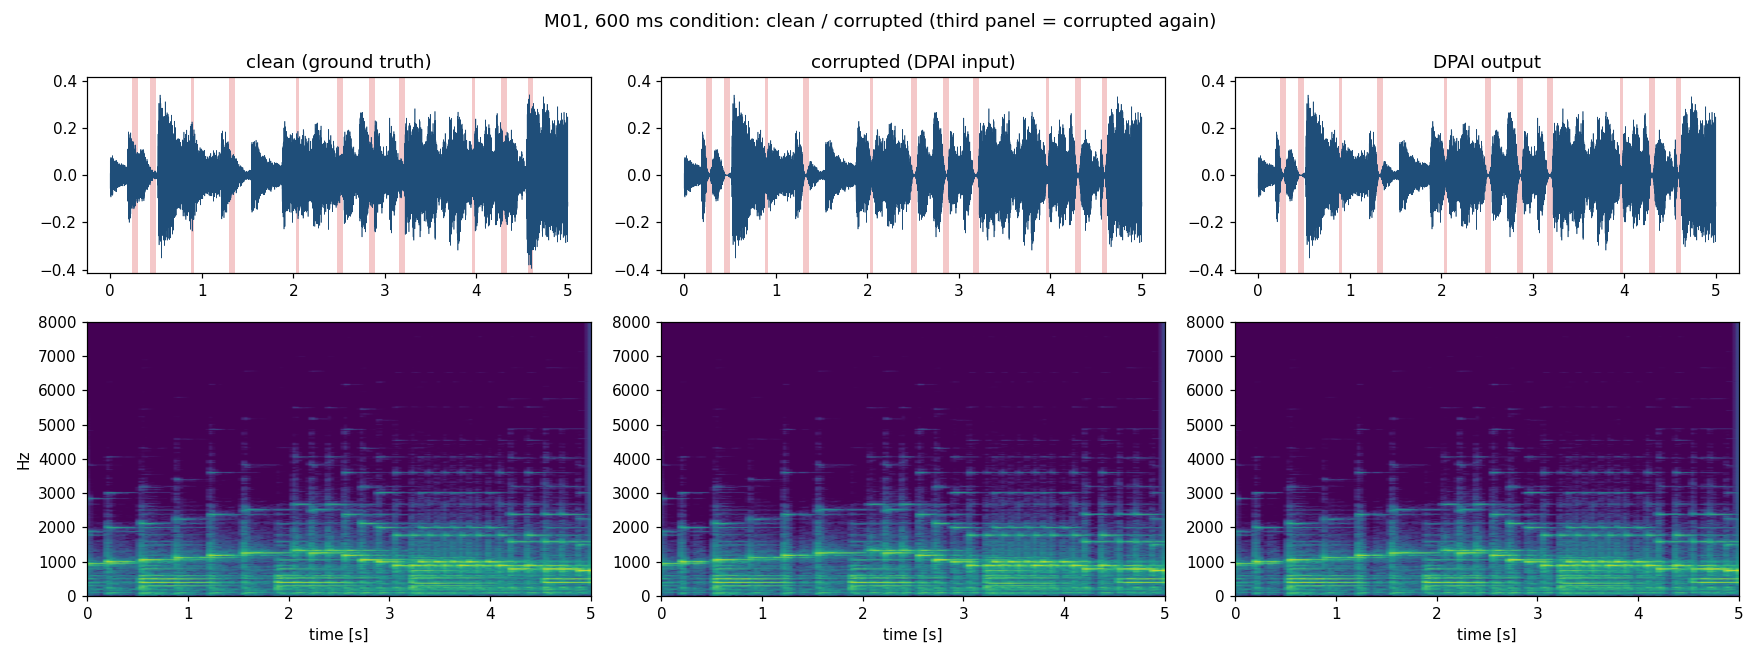

clean


corrupted


9 OK


In [21]:
problems = []
for (clip, cond), (info, mask) in MASKS.items():
    clean, s1 = sf.read(os.path.join(D["clean"], f"{clip}.wav"))
    corr, s2 = sf.read(os.path.join(D["corrupted"], f"{cond}ms", f"{clip}.wav"))
    if s1 != 16000 or s2 != 16000 or len(clean) != MP.CLIP_N or len(corr) != MP.CLIP_N or corr.ndim != 1:
        problems.append(f"{clip}/{cond}: format"); continue
    reg = RE.regions(info["gap_frames"])
    obs = RE.region_metrics(clean, corr, reg["observed"])["nmse_db"]
    miss = RE.region_metrics(clean, corr, reg["missing"])["nmse_db"]
    if obs is not None and obs > -60: problems.append(f"{clip}/{cond}: observed region differs ({obs:.1f} dB)")
    if miss is None or miss < -10:   problems.append(f"{clip}/{cond}: gaps not removed ({miss})")
print(f"all {len(MASKS)} pairs OK" if not problems else problems)
ex_clip, ex_cond = META["clip_id"].iloc[0], 600
info, mask = MASKS[(ex_clip, ex_cond)]
c0, _ = sf.read(os.path.join(D["clean"], f"{ex_clip}.wav")); k0, _ = sf.read(os.path.join(D["corrupted"], f"{ex_cond}ms", f"{ex_clip}.wav"))
RE.plot_example(c0, k0, k0, info["gap_frames"], f"{ex_clip}, {ex_cond} ms condition: clean / corrupted (third panel = corrupted again)",
                os.path.join(D["plots"], "example_clean_vs_corrupted.png"))
display(Image(os.path.join(D["plots"], "example_clean_vs_corrupted.png")))
print("clean"); display(Audio(c0, rate=16000)); print("corrupted"); display(Audio(k0, rate=16000))
if problems:
    raise RuntimeError("Clean/corrupted verification failed - see above.")
print("9 OK")

## 10. Run the ORIGINAL DPAI
### 10.1 Get DPAI, create the working copy, compile the kernel, verify
**What:**
1. clones the official repository and checks out commit `75074c9` (the latest commit, the audited version). If cloning is impossible, upload `dpai-main.zip` when asked;
2. makes a **working copy** with three documented harness patches. The original stays untouched, and this is checked with SHA-256:
   * **P1** `librosa.display.waveplot` → `waveshow` (the function was removed in librosa 0.10; it only affects 3 figures),
   * **P2** if `DPAI_MASK_FILE` is set, the frame mask is loaded from that saved file instead of the hard-coded demo mask (the paper protocol). Without it the script is unchanged,
   * **P3** the final network output spectrogram is saved (output only);
3. compiles the **unmodified** harmonic-convolution kernel with `CUDAExtension`. The repository's own `setup.py` produces an un-importable module on current PyTorch;
4. verifies: the kernel against its reference, **2,015,252 parameters** (= paper), and the **leakage checks**:
   * *static:* the loss is computed only on `out * mask` vs `ref * mask`; only the training loss is back-propagated; the network input is noise from `get_noise()`;
   * *dynamic:* replacing the clean spectrogram inside the masked frames with random values gives **exactly the same loss and the same gradients**, so the model cannot use the ground truth of the gaps.

In [22]:
if not GPU_OK:
    raise RuntimeError("Section 10 needs a GPU. ACTION: Runtime > Change runtime type > GPU, then Run all (finished work is kept).")
nvcc = shutil.which("nvcc") or ("/usr/local/cuda/bin/nvcc" if os.path.exists("/usr/local/cuda/bin/nvcc") else None)
if not nvcc:
    raise RuntimeError("nvcc not found - use a standard Colab GPU runtime.")
os.environ["PATH"] = os.path.dirname(nvcc) + os.pathsep + os.environ["PATH"]
os.environ.setdefault("CUDA_HOME", os.path.dirname(os.path.dirname(nvcc)))
NVCC_VERSION = subprocess.run([nvcc, "--version"], capture_output=True, text=True).stdout.strip().splitlines()[-1]

ORIG = os.path.join(BASE, "dpai_original"); WORK = os.path.join(BASE, "dpai_work")
if not os.path.isfile(os.path.join(ORIG, "src", "script.py")):
    shutil.rmtree(ORIG, ignore_errors=True)
    r = subprocess.run(["git", "clone", "-q", DPAI_REPO_URL, ORIG], capture_output=True, text=True)
    if r.returncode == 0:
        subprocess.run(["git", "-C", ORIG, "checkout", "-q", DPAI_COMMIT], check=True)
    else:
        print("git clone failed:", r.stderr[-300:]); print("Please upload dpai-main.zip")
        from google.colab import files
        up = files.upload(); z = [k for k in up if k.endswith(".zip")][0]
        with zipfile.ZipFile(z) as zf: zf.extractall(BASE + "/dpai_zip")
        root = os.path.dirname(os.path.dirname(glob.glob(BASE + "/dpai_zip/**/src/script.py", recursive=True)[0]))
        shutil.move(root, ORIG)
head = subprocess.run(["git", "-C", ORIG, "rev-parse", "HEAD"], capture_output=True, text=True).stdout.strip() or "zip upload (no git metadata)"
print("DPAI source:", ORIG, "| commit:", head)
r = subprocess.run([sys.executable, os.path.join(SUPPORT_DIR, "prepare_working_copy.py"), "--repo-root", ORIG, "--work-dir", WORK,
                    "--support-dir", SUPPORT_DIR], capture_output=True, text=True)
print(r.stdout[-2500:], r.stderr[-1500:])
if r.returncode != 0:
    raise RuntimeError("working copy preparation failed")
SRC = os.path.join(WORK, "src"); HL = os.path.join(SRC, "models", "HarmonicLowering")
if not glob.glob(os.path.join(HL, "interp_same*.so")):
    env = dict(os.environ, TORCH_CUDA_ARCH_LIST=f"{GPU_CAP[0]}.{GPU_CAP[1]}", MAX_JOBS="2")
    r = subprocess.run([sys.executable, "setup_interp_same_cuda.py", "build_ext", "--inplace"], cwd=HL, env=env, capture_output=True, text=True)
    open(os.path.join(D["logs"], "build_interp_same.log"), "w").write(r.stdout + r.stderr)
    if r.returncode != 0 or not glob.glob(os.path.join(HL, "interp_same*.so")):
        print(r.stderr[-4000:]); raise RuntimeError("CUDA kernel build failed (log in logs/build_interp_same.log)")
for p in [HL, os.path.join(SRC, "utils"), SRC]:
    if p not in sys.path: sys.path.insert(0, p)
import interp_same, interp_same_reference as REF
import models.HarmonicLowering.interp_function as IF
from models.mulresunet import MulResUnet
import utils.common_utils as CU
torch.manual_seed(0); x = torch.randn(1, 3, 64, 17, device="cuda"); worst = 0.0
for k in range(1, 5):
    for n in range(1, 4):
        idx, w = IF.make_detail(k, n, device=x.device)
        a = torch.empty_like(x); interp_same.interp_affine(x, a, idx, w, k, n)
        b = torch.empty_like(x); REF.interp_affine(x, b, idx, w, k, n); worst = max(worst, (a - b).abs().max().item())
print(f"kernel self-test: max |difference| = {worst:.1e}"); assert worst < 1e-5

S = json.load(open(os.path.join(WORK, NET_JSON)))
def build_net():
    return MulResUnet(num_input_channels=2, num_output_channels=2, **{k: S[k] for k in [
        "num_channels_down", "num_channels_up", "num_channels_skip", "kernel_size_down", "kernel_size_up", "kernel_size_skip",
        "kernel_size_downsampling", "conv_type_down", "conv_type_up", "conv_type_res", "conv_type_downsampling", "conv_type_out",
        "anchor_down", "anchor_up", "anchor_res", "anchor_downsampling", "anchor_out", "upsample_mode", "dropout"]},
        alpha=1, last_act_fun=None, need_bias=True, act_fun="LeakyReLU").type(torch.cuda.FloatTensor)
net = build_net(); N_PARAMS = int(sum(p.numel() for p in net.parameters()))
print("parameters:", N_PARAMS, "(paper: 2015252)"); assert N_PARAMS == 2015252

# ---- leakage checks
src_txt = open(os.path.join(SRC, "script.py")).read()
STATIC = {"loss_on_observed_only": "compute_loss(device, out * mask_tensor, ref_tensor * mask_tensor" in src_txt,
          "only_training_loss_backpropagated": "total_loss.backward()" in src_txt and "total_validation_loss.backward" not in src_txt,
          "network_input_is_noise": "net_input = get_noise(" in src_txt}
clip0 = META["clip_id"].iloc[0]; info0, mask0 = MASKS[(clip0, 600)]
y0, _ = librosa.load(os.path.join(D["clean"], f"{clip0}.wav"), sr=16000, offset=0, duration=5)
X0 = librosa.stft(y0)[:1024, :208]
ref = torch.from_numpy(np.stack((X0.real, X0.imag)))[None].type(torch.cuda.FloatTensor)
m = torch.from_numpy(np.stack((mask0, mask0)))[None].type(torch.cuda.FloatTensor)
tampered = ref.clone(); g = torch.Generator(device="cuda").manual_seed(1)
tampered[m == 0] = torch.randn(int((m == 0).sum()), device="cuda", generator=g) * 10
torch.manual_seed(0); z = CU.get_noise(2, "noise", (1024, X0.shape[1]), noise_type="uniform").type(torch.cuda.FloatTensor)
out = net(z)
params = [p for p in net.parameters()]
l1 = CU.compute_loss(torch.device("cuda"), out * m, ref * m, 1.0, 1.0, 1.0, 1.0)
g1 = torch.autograd.grad(l1, params, retain_graph=True)
l2 = CU.compute_loss(torch.device("cuda"), out * m, tampered * m, 1.0, 1.0, 1.0, 1.0)
g2 = torch.autograd.grad(l2, params)
max_grad_diff = max(
    (a - b).abs().max().item()
    for a, b in zip(g1, g2)
)

DYNAMIC = {
    "loss_identical": bool(l1.item() == l2.item()),
    "gradients_close": bool(all(
        torch.allclose(a, b, rtol=1e-5, atol=1e-6)
        for a, b in zip(g1, g2)
    )),
    "max_gradient_difference": max_grad_diff,
    "tampered_differs_in_gaps": bool((tampered != ref).any().item())
}

LEAKAGE = {"static": STATIC, "dynamic": DYNAMIC}
print(json.dumps(LEAKAGE, indent=1))
LEAKAGE = {"static": STATIC, "dynamic": DYNAMIC}
print(json.dumps(LEAKAGE, indent=1))
del net, out, g1, g2, ref, tampered, m, z; torch.cuda.empty_cache()
if not all(STATIC.values()) or not DYNAMIC["loss_identical"] or not DYNAMIC["gradients_close"] or not DYNAMIC["tampered_differs_in_gaps"]:
    raise RuntimeError("Leakage check failed - do not run the baseline.")
json.dump({"dpai_repo": DPAI_REPO_URL, "commit": head, "n_params": N_PARAMS, "kernel_selftest_max_diff": worst,
           "nvcc": NVCC_VERSION, "leakage_checks": LEAKAGE,
           "patches": json.load(open(os.path.join(WORK, "WORKING_COPY_PATCHES.json")))["patches"]},
          open(os.path.join(D["metadata"], "dpai_setup.json"), "w"), indent=1, default=str)
shutil.copy(os.path.join(WORK, "WORKING_COPY_PATCHES.diff"), os.path.join(D["metadata"], "dpai_working_copy_patches.diff"))
print("10.1 OK")

DPAI source: /content/dpai_original | commit: 75074c9022e818685d3ae9bbfac894e30b9e368a
Working copy ready: /content/dpai_work
Original repository verified unchanged (115 files hashed).
  patched src/script.py (1x): P2 (experiment harness): if the environment variable DPAI_MASK_FILE is set, the frame mask...
  patched src/script.py (1x): P3 (output only): saves the final network output spectrogram (the same array the script al...
  patched src/script.py (3x): librosa.display.waveplot was removed in librosa 0.10; waveshow is its replacement. Only af...
  removed stale build folders from the copy: src/models/HarmonicLowering/build, src/models/HarmonicLowering/dist, src/models/HarmonicLowering/interp_same.egg-info
 
kernel self-test: max |difference| = 2.4e-07
parameters: 2015252 (paper: 2015252)


/content/dpai_work/src/utils/common_utils.py:246: UserWarning: A window was not provided. A rectangular window will be applied.Please provide the same window used by stft to make the inversion lossless.To suppress this warning and use a rectangular window, explicitly set `window=torch.ones(n_fft, device=<device>)`. (Triggered internally at /pytorch/aten/src/ATen/native/SpectralOps.cpp:1035.)
  input_audio = torch.istft(input_spectrogram, n_fft=2047)


{
 "static": {
  "loss_on_observed_only": true,
  "only_training_loss_backpropagated": true,
  "network_input_is_noise": true
 },
 "dynamic": {
  "loss_identical": true,
  "gradients_close": true,
  "max_gradient_difference": 3.6135315895080566e-07,
  "tampered_differs_in_gaps": true
 }
}
{
 "static": {
  "loss_on_observed_only": true,
  "only_training_loss_backpropagated": true,
  "network_input_is_noise": true
 },
 "dynamic": {
  "loss_identical": true,
  "gradients_close": true,
  "max_gradient_difference": 3.6135315895080566e-07,
  "tampered_differs_in_gaps": true
 }
}
10.1 OK


### 10.2 Configuration, smoke test and runtime estimate
**What:** prints the exact DPAI configuration, then runs a **smoke test**: the first planned run, for `SMOKE_EPOCHS` epochs. It checks every output and evaluation step, and measures the seconds per epoch on this GPU. From that it prints the expected time per 5000-epoch run, the whole matrix, and how many runs fit into this session. **Smoke-test numbers are not results.**

| | A. Paper (Sec. III–IV) | B. Repository (`script.py`, `nets/best.json`) | Used here |
|---|---|---|---|
| sampling rate / clip | 16 kHz, 5 s | `sr=16000`, `--audio_len 5` | 16 kHz, 5.000 s |
| STFT | complex, real+imag channels | n_fft 2048, hop 512, Hann; `X[:1024,:208]` | same (unchanged code) |
| network | MultiResUNet, 5 levels, harmonic conv in encoder, Table I anchors | `best.json` (2,015,252 params) | `best.json` |
| input | uniform noise, variance 0.1; +0.03 noise per iteration | `0.1·U(0,1)`, `reg_noise_std=0.03` | same |
| loss | MSE(Re,Im) + 0.1·MSS(sc, log, lin, phase) | `compute_loss`, α=β=γ=δ=1 | same |
| optimiser / lr / epochs | Adam / **0.01** / 5000 | Adam / **0.001** (default) / 5000 | Adam / **0.01** / 5000 |
| gaps | random 40–80 ms, 200–1000 ms total | hard-coded 5×5 frames (paper code commented out) | paper protocol (section 7) via P2 |
| reconstruction | f_θ*(Z) → iSTFT | `net(net_input)` → `librosa.istft` | same + P3 saves the spectrogram |

In [23]:
def script_args(clip, epochs, results_dir):
    return ["--source", os.path.join(D["clean"], f"{clip}.wav"), "--net", os.path.join("..", NET_JSON), "--epochs", epochs,
            "--lr", LEARNING_RATE, "--offset", 0, "--audio_len", 5, "--input_noise", "uniform", "--results_dir", results_dir]
DPAI_CONFIG = {"entry point": "src/script.py (unchanged algorithm; patches P1-P3)", "network": NET_JSON + " (2,015,252 parameters)",
               "epochs": EPOCHS, "optimizer": "Adam (hard-coded)", "learning rate": LEARNING_RATE,
               "input": "uniform noise 0.1*U(0,1), depth 2, +0.03*N(0,1) per iteration", "loss": "MSE + 0.1*MultiResolutionSTFT (alpha=beta=gamma=delta=1)",
               "STFT": "n_fft 2048, hop 512, Hann, 1024 bins x 157 frames", "seed": DPAI_SEED}
for k, v in DPAI_CONFIG.items(): print(f"  {k:16s} {v}")

PLAN = [(c, cond) for cond in RUN_ORDER_MS for c in META["clip_id"]]
def run_dir_of(clip, cond): return os.path.join(D["recon"], f"{clip}_gap{cond}")
def is_done(clip, cond): return os.path.isfile(os.path.join(run_dir_of(clip, cond), "DONE.json"))

def execute(clip, cond, epochs, scratch_root, timeout_s):
    info, mask = MASKS[(clip, cond)]
    shutil.rmtree(scratch_root, ignore_errors=True); os.makedirs(scratch_root)
    os.environ["DPAI_MASK_FILE"] = os.path.join(D["masks"], f"{cond}ms", f"{clip}.npy")
    try:
        res = RUN.run_dpai(SUPPORT_DIR, SRC, [], script_args(clip, epochs, scratch_root), os.path.join(scratch_root, "run.log"),
                           seed=DPAI_SEED, timeout_s=timeout_s, echo_every=max(1, epochs // 100))
    finally:
        os.environ.pop("DPAI_MASK_FILE", None)
    return res

def evaluate_saved(clip, cond, out_dir, runtime_s, status):
    info, mask = MASKS[(clip, cond)]
    meta = META.set_index("clip_id").loc[clip].to_dict(); meta["clip_id"] = clip
    rows, pq, chk, sigs = RE.evaluate_run(os.path.join(D["clean"], f"{clip}.wav"), os.path.join(D["corrupted"], f"{cond}ms", f"{clip}.wav"),
                                          out_dir, info, mask, meta["category"], clean_md5=meta["clean_md5"])
    repo = json.load(open(os.path.join(out_dir, "metrics.json"))) if os.path.isfile(os.path.join(out_dir, "metrics.json")) else {}
    flat = RE.flatten(meta, cond, info, rows, pq, chk, runtime_s, status, repo)
    return flat, rows, chk, sigs

first = next(((c, k) for c, k in PLAN if not is_done(c, k)), PLAN[0])
SMOKE = execute(first[0], first[1], SMOKE_EPOCHS, os.path.join(SCRATCH, "smoke"), 30 * 60)
print("SMOKE TEST status:", SMOKE["status"], f"({SMOKE['seconds']} s)")
if SMOKE["status"] != "ok":
    print("".join(SMOKE["tail"])); raise RuntimeError("Smoke test failed:\n  " + "\n  ".join(SMOKE["diagnosis"] or ["see the log above"]))
sm_dir = glob.glob(os.path.join(SCRATCH, "smoke", "*", first[0]))[0]
sm_flat, _, sm_chk, _ = evaluate_saved(first[0], first[1], sm_dir, SMOKE["seconds"], "smoke")
print("SMOKE TEST checks:", "PASSED" if not sm_chk["problems"] else sm_chk["problems"])
print("SMOKE TEST (NOT A RESULT) NMSE missing:", round(sm_flat["dpai_missing_nmse_db"], 2), "dB")
SEC_PER_EPOCH = RUN.seconds_per_epoch(SMOKE) or SMOKE["seconds"] / SMOKE_EPOCHS
OVERHEAD = max(20.0, SMOKE["seconds"] - SEC_PER_EPOCH * SMOKE_EPOCHS) + 15
EST_RUN_S = SEC_PER_EPOCH * EPOCHS + OVERHEAD
remaining = [(c, k) for c, k in PLAN if not is_done(c, k)]
left_s = MAX_SESSION_HOURS * 3600 - (time.time() - SESSION_START)
print(f"\nmeasured {SEC_PER_EPOCH:.3f} s/epoch -> about {EST_RUN_S/60:.1f} min per {EPOCHS}-epoch run")
print(f"full matrix: {len(PLAN)} runs = {len(PLAN)*EST_RUN_S/3600:.1f} GPU-hours; remaining {len(remaining)} runs = {len(remaining)*EST_RUN_S/3600:.1f} h")
print(f"core matrix (200/1000/600 ms): {3*len(META)} runs = {3*len(META)*EST_RUN_S/3600:.1f} h")
print(f"this session can run about {max(0, int(left_s // EST_RUN_S))} runs (MAX_SESSION_HOURS={MAX_SESSION_HOURS})")
json.dump({"seconds_per_epoch": SEC_PER_EPOCH, "estimated_run_min": EST_RUN_S / 60, "gpu": VERSIONS["gpu"], "measured": datetime.now().isoformat(timespec="seconds")},
          open(os.path.join(D["logs"], f"speed_{datetime.now():%Y%m%d_%H%M%S}.json"), "w"), indent=1)
print("10.2 OK")

  entry point      src/script.py (unchanged algorithm; patches P1-P3)
  network          nets/best.json (2,015,252 parameters)
  epochs           5000
  optimizer        Adam (hard-coded)
  learning rate    0.01
  input            uniform noise 0.1*U(0,1), depth 2, +0.03*N(0,1) per iteration
  loss             MSE + 0.1*MultiResolutionSTFT (alpha=beta=gamma=delta=1)
  STFT             n_fft 2048, hop 512, Hann, 1024 bins x 157 frames
  seed             0
  [run_dpai_seeded] seed=0  entry point=/content/dpai_work/src/script.py
  [run_dpai_seeded] script arguments: --source /content/drive/MyDrive/DPAI_real_baseline/dataset/clean/M05.wav --net ../nets/best.json --epochs 30 --lr 0.01 --offset 0 --audio_len 5 --input_noise uniform --results_dir /content/dpai_scratch/smoke
  [PROCESSING sample: M05.wav]
  Number of params: 2015252
  Starting optimization with ADAM
  [   30.2s] [M05.wav] Iteration 00000/00030:    Loss 37.658157 | Validation loss 1.689268
  [   34.2s] [M05.wav] Iteration 00010

### 10.3 Baseline runs (resumable)
**What:** works through the plan in the order of `RUN_ORDER_MS` (all clips at 200 ms, then 1000, 600, 400, 800). It skips runs that are already finished, and stops starting new runs when `MAX_SESSION_HOURS` would be exceeded. Each run:
1. runs DPAI's `script.py` with the saved mask (5000 epochs, Adam, lr 0.01, seed 0);
2. is evaluated immediately against the clean clip (section 11's code);
3. has its outputs copied to `reconstructions/<clip>_gap<cond>/`: the DPAI output WAV (on the original time axis), the output with observed context, the output spectrogram, the mask DPAI used, the script's own metrics, losses and figures, the run log, and `DONE.json`.

Failed runs get `FAILED.json` with the reason and are retried in the next session. **Keep the browser tab open.** If Colab disconnects, run all again later: completed runs are kept.

In [26]:
done_now, fails_in_row = 0, 0
for clip, cond in PLAN:
    if is_done(clip, cond):
        continue
    elapsed = time.time() - SESSION_START
    if elapsed + EST_RUN_S > MAX_SESSION_HOURS * 3600:
        print(f"Session budget reached after {elapsed/3600:.1f} h - run all again in a new session to continue."); break
    rid = f"{clip}_gap{cond}"; print(f"\n=== {rid}  ({sum(is_done(c, k) for c, k in PLAN)}/{len(PLAN)} done) ===")
    res = execute(clip, cond, EPOCHS, os.path.join(SCRATCH, rid), timeout_s=max(3 * EST_RUN_S, 1800))
    dst = run_dir_of(clip, cond); os.makedirs(dst, exist_ok=True)
    if res["status"] != "ok":
        fails_in_row += 1
        json.dump({k: v for k, v in res.items() if k != "losses_printed"}, open(os.path.join(dst, "FAILED.json"), "w"), indent=1, default=str)
        shutil.copy(res["log_path"], os.path.join(dst, "run.log"))
        print("FAILED:", res["diagnosis"])
        if fails_in_row >= 2:
            raise RuntimeError("Two runs failed in a row - stopping. See FAILED.json in reconstructions/.")
        continue
    fails_in_row = 0
    out_dir = glob.glob(os.path.join(SCRATCH, rid, "*", clip))[0]
    flat, rows, chk, sigs = evaluate_saved(clip, cond, out_dir, res["seconds"], "ok")
    sf.write(os.path.join(dst, "dpai_reconstruction.wav"), sigs["dpai"].astype(np.float32), 16000, subtype="FLOAT")
    sf.write(os.path.join(dst, "dpai_reconstruction_with_observed_context.wav"), sigs["dpai_ctx"].astype(np.float32), 16000, subtype="FLOAT")
    for f in ["output_spectrogram.npy", "mask.npy", "metrics.json", "losses.json", "hparams.json", "loss.png", "validation_loss.png",
              "magnitude_reconstructed.png", "magnitude_original_masked.png", "audio_reconstructed.wav"]:
        if os.path.isfile(os.path.join(out_dir, f)):
            shutil.copy(os.path.join(out_dir, f), os.path.join(dst, ("repo_" + f) if f in ("metrics.json", "audio_reconstructed.wav") else f))
    shutil.copy(res["log_path"], os.path.join(dst, "run.log"))
    if os.path.isfile(os.path.join(dst, "FAILED.json")): os.remove(os.path.join(dst, "FAILED.json"))
    json.dump({"flat": flat, "rows": rows, "checks": chk, "finished": datetime.now().isoformat(timespec="seconds")},
              open(os.path.join(dst, "DONE.json"), "w"), indent=1, default=str)
    shutil.rmtree(os.path.join(SCRATCH, rid), ignore_errors=True)
    done_now += 1
    print(f"  done in {res['seconds']/60:.1f} min | NMSE missing {flat['dpai_missing_nmse_db']:.2f} dB "
          f"(corrupted {flat['corrupted_missing_nmse_db']:.2f} dB) | checks {'OK' if flat['checks_passed'] else chk['problems']}")
print(f"\n10.3 finished: {done_now} runs this session; {sum(is_done(c, k) for c, k in PLAN)}/{len(PLAN)} in total")


=== M05_gap200  (4/100 done) ===
  [run_dpai_seeded] seed=0  entry point=/content/dpai_work/src/script.py
  [run_dpai_seeded] script arguments: --source /content/drive/MyDrive/DPAI_real_baseline/dataset/clean/M05.wav --net ../nets/best.json --epochs 5000 --lr 0.01 --offset 0 --audio_len 5 --input_noise uniform --results_dir /content/dpai_scratch/M05_gap200
  [PROCESSING sample: M05.wav]
  Number of params: 2015252
  Starting optimization with ADAM
  [  220.9s] [M05.wav] Iteration 00490/05000:    Loss 8.270988 | Validation loss 0.659454
  [  416.3s] [M05.wav] Iteration 00990/05000:    Loss 1.505676 | Validation loss 0.352982
  [  609.7s] [M05.wav] Iteration 01490/05000:    Loss 0.626442 | Validation loss 0.228199
  [  802.9s] [M05.wav] Iteration 01990/05000:    Loss 0.274969 | Validation loss 0.160221
  [  996.0s] [M05.wav] Iteration 02490/05000:    Loss 5.612621 | Validation loss 0.512621
  [ 1189.1s] [M05.wav] Iteration 02990/05000:    Loss 1.712440 | Validation loss 0.352566
  [ 138

KeyboardInterrupt: 

## 11. Evaluate the baseline
**Reference:** the clean clip (ground truth). **Evaluated signals:** the corrupted input ("before"), the DPAI output, and the DPAI output with the observed frames taken from the input.
**Regions** (from the saved mask; frame *l* is centred on sample 512·*l*):
* **missing** — the samples owned by masked frames, `[512a−256, 512(b−1)+256)`. **This is the primary region.**
* **transition** — touched by a masked frame's 2048-sample window but not missing (overlap-add zone);
* **observed** — untouched by any masked frame (the model was fitted to these, so a low error here does not show inpainting quality);
* **all** — the whole 5-s clip.

**Metrics** (x = clean, x̂ = evaluated signal, sums over the region):
NMSE [dB] = 10·log10(Σ(x̂−x)² / Σx²) (paper Eq. 16; lower is better) · SNR [dB] = −NMSE · RMSE = √mean(x̂−x)² · NRMSE = √(Σ(x̂−x)²/Σx²) · wide-band PESQ and ΔPESQ = PESQ(x, x̂) − PESQ(x, corrupted) for **speech only** (PESQ is not valid for music) · runtime.

This cell rebuilds `metrics.csv` and `metrics.json` from every finished run, so it can be re-run at any time.

In [25]:
done_files = sorted(glob.glob(os.path.join(D["recon"], "*", "DONE.json")))

if not done_files:
    raise RuntimeError("No finished runs yet - run section 10 first.")

recs = [json.load(open(f)) for f in done_files]

DF = pd.DataFrame([r["flat"] for r in recs]).sort_values(
    ["gap_condition_ms", "clip_id"]
).reset_index(drop=True)

LONG = pd.DataFrame([
    {
        **{
            "run_id": r["flat"]["run_id"],
            "clip_id": r["flat"]["clip_id"],
            "category": r["flat"]["category"],
            "gap_condition_ms": r["flat"]["gap_condition_ms"]
        },
        **row
    }
    for r in recs
    for row in r["rows"]
])

DF.to_csv(os.path.join(D["metrics"], "metrics.csv"), index=False)

LONG.to_csv(os.path.join(D["metrics"], "metrics_long.csv"), index=False)

json.dump(
    {
        "generated": datetime.now().isoformat(timespec="seconds"),
        "runs": [r["flat"] for r in recs]
    },
    open(os.path.join(D["metrics"], "metrics.json"), "w"),
    indent=1,
    default=str
)

print(f"{len(DF)} finished runs; checks passed: {int(DF['checks_passed'].sum())}")

display(DF.round(3))

4 finished runs; checks passed: 4


,run_id,clip_id,category,genre_or_category,musan_source,gap_condition_ms,gap_count,total_gap_ms,gap_durations_ms,seed,...,dpai_ctx_all_nrmse,dpai_ctx_all_nmse_lin,repo_nmse_spectrogram,repo_nmse_audio,repo_nmse_audio_masked_part,repo_pesq_before,repo_pesq_after,repo_elapsed_time,repo_last_training_loss,repo_last_validation_loss
0,M01_gap200,M01,music,"westernart,classical",hd-classical,200,4,192.0,"[32.0, 64.0, 64.0, 32.0]",202600200,...,0.041,0.002,-19.644,-21.482,-10.783,4.077,4.037,0:34:39,0.387,0.131
1,M02_gap200,M02,music,"westernart,romantic",hd-classical,200,4,192.0,"[32.0, 32.0, 64.0, 64.0]",202601200,...,0.036,0.001,-23.334,-25.252,-15.255,3.653,4.361,0:34:18,0.338,0.102
2,M03_gap200,M03,music,"westernart,romantic",hd-classical,200,4,192.0,"[64.0, 32.0, 64.0, 32.0]",202602200,...,0.054,0.003,-19.796,-21.540,-11.459,3.604,4.399,0:34:34,0.442,0.135
3,M04_gap200,M04,music,latin,jamendo,200,4,192.0,"[32.0, 64.0, 64.0, 32.0]",202603200,...,0.084,0.007,-11.595,-12.437,-7.928,3.846,2.177,0:34:22,1.359,0.271


In [24]:
done_files = sorted(glob.glob(os.path.join(D["recon"], "*", "DONE.json")))
if not done_files:
    raise RuntimeError("No finished runs yet - run section 10 first.")
recs = [json.load(open(f)) for f in done_files]
DF = pd.DataFrame([r["flat"] for r in recs]).sort_values(["gap_condition_ms", "clip_id"]).reset_index(drop=True)
LONG = pd.DataFrame([{**{"run_id": r["flat"]["run_id"], "clip_id": r["flat"]["clip_id"], "category": r["flat"]["category"],
                        "gap_condition_ms": r["flat"]["gap_condition_ms"]}, **row} for r in recs for row in r["rows"]])
DF.to_csv(os.path.join(D["metrics"], "metrics.csv"), index=False)
LONG.to_csv(os.path.join(D["metrics"], "metrics_long.csv"), index=False)
json.dump({"generated": datetime.now().isoformat(timespec="seconds"), "runs": [r["flat"] for r in recs]},
          open(os.path.join(D["metrics"], "metrics.json"), "w"), indent=1, default=str)
print(f"{len(DF)} finished runs; checks passed: {int(DF['checks_passed'].sum())}")
display(DF[["run_id", "category", "gap_count", "total_gap_ms", "corrupted_missing_nmse_db", "dpai_missing_nmse_db", "dpai_missing_rmse",
            "dpai_all_nmse_db", "dpai_observed_nmse_db", "delta_pesq", "runtime_s", "checks_passed"]].round(3))

4 finished runs; checks passed: 4


KeyError: "['delta_pesq'] not in index"

## 12. Aggregate metrics
**What:** per gap condition, for all clips and separately for music and speech: mean, standard deviation, median and a 95 % bootstrap confidence interval of the mean (2,000 resamples, seeded). It also gives the **paper-style** NMSE (Eq. 16: 10·log10 of the mean linear error ratio). Only runs whose checks passed are used.

In [ ]:
AGG = RE.aggregate(DF, seed=SELECTION_SEED)
AGG.to_csv(os.path.join(D["metrics"], "aggregate.csv"), index=False)
json.dump(AGG.to_dict(orient="records"), open(os.path.join(D["metrics"], "aggregate.json"), "w"), indent=1, default=str)
cols = ["gap_condition_ms", "category", "n_runs", "dpai_missing_nmse_db_mean", "dpai_missing_nmse_db_std", "dpai_missing_nmse_db_ci95_lo",
        "dpai_missing_nmse_db_ci95_hi", "corrupted_missing_nmse_db_mean", "dpai_all_nmse_db_mean", "paper_eq16_dpai_missing_db", "delta_pesq_mean"]
display(AGG[[c for c in cols if c in AGG]].round(2))

## 13. Plots
NMSE in the gaps and overall, and ΔPESQ, against cumulative gap duration (mean ± std; music, speech, all); a per-clip heat map; and the best, median and worst runs at 600 ms (waveforms and spectrograms of clean, corrupted and DPAI output).

In [ ]:
RE.plot_condition_curves(AGG, os.path.join(D["plots"], "nmse_vs_gap_duration.png"))
RE.plot_per_clip(DF, os.path.join(D["plots"], "per_clip_nmse_missing.png"))
ok = DF[(DF["status"] == "ok") & DF["checks_passed"]]
pick_cond = 600 if (ok["gap_condition_ms"] == 600).any() else ok["gap_condition_ms"].iloc[0]
sub = ok[ok["gap_condition_ms"] == pick_cond].sort_values("dpai_missing_nmse_db")
for label, row in (("best", sub.iloc[0]), ("median", sub.iloc[len(sub) // 2]), ("worst", sub.iloc[-1])):
    clip = row["clip_id"]; info, _ = MASKS[(clip, pick_cond)]
    c, _ = sf.read(os.path.join(D["clean"], f"{clip}.wav")); k, _ = sf.read(os.path.join(D["corrupted"], f"{pick_cond}ms", f"{clip}.wav"))
    o, _ = sf.read(os.path.join(run_dir_of(clip, pick_cond), "dpai_reconstruction.wav"))
    RE.plot_example(c, k, o, info["gap_frames"], f"{label}: {clip} ({row['category']}), {pick_cond} ms, NMSE missing {row['dpai_missing_nmse_db']:.2f} dB",
                    os.path.join(D["plots"], f"example_{label}_{pick_cond}ms.png"))
for f in sorted(glob.glob(os.path.join(D["plots"], "*.png"))):
    print(os.path.basename(f)); display(Image(f))

## 14. Save results
**What:** writes `logs/environment.json` (Python, PyTorch, librosa, GPU, CUDA, nvcc, DPAI commit, MUSAN checksum, seeds) and creates `DPAI_real_baseline_results.zip`, which contains everything except the copied raw MUSAN files.

In [ ]:
ENV = {**VERSIONS, "nvcc": NVCC_VERSION, "dpai_setup": json.load(open(os.path.join(D["metadata"], "dpai_setup.json"))),
       "dataset_source": DATASET_SOURCE, "selection_seed": SELECTION_SEED, "dpai_seed": DPAI_SEED,
       "mask_seed_rule": "SELECTION_SEED*100000 + clip_index*1000 + condition_ms", "written": datetime.now().isoformat(timespec="seconds")}
json.dump(ENV, open(os.path.join(D["logs"], "environment.json"), "w"), indent=1, default=str)
zip_path = os.path.join(BASE, "DPAI_real_baseline_results.zip")
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for root, _, fnames in os.walk(PROJECT_DIR):
        if os.sep + os.path.join("dataset", "raw") in root:
            continue
        for f in fnames:
            p = os.path.join(root, f); z.write(p, os.path.relpath(p, os.path.dirname(PROJECT_DIR)))
print("results ZIP:", zip_path, f"{os.path.getsize(zip_path)/1e6:.1f} MB")
try:
    from google.colab import files; files.download(zip_path)
except ImportError:
    pass

## 15. Final baseline summary
**What:** writes `reports/baseline_summary.md`, covering the dataset, clips, audio types, preprocessing, gap conditions, DPAI configuration, runtime, average metrics with std and CI, per-clip results and limitations, and prints it. If the matrix is not complete yet, the summary says how many runs it is based on.

In [ ]:
ctx = {"archive_sha256": DATASET_SOURCE.get("sha256"), "seed": SELECTION_SEED, "duplicate_issues": DUPS.get("issues"),
       "max_ncc": DUPS.get("max_ncc_between_clips"), "dpai_config": DPAI_CONFIG}
RE.write_summary(os.path.join(D["reports"], "baseline_summary.md"), ctx, META, EXP, DF, AGG)
print(open(os.path.join(D["reports"], "baseline_summary.md")).read())
print(f"\nCompleted runs: {len(DF)}/{len(PLAN)}" + ("" if len(DF) == len(PLAN) else "  -> run the notebook again in a new session to continue."))